
# Lumen Technologies, Inc. (LUMN) — Financial Analysis with Expanded Factor and Peer Comparisons

This notebook provides a single-company analysis of **Lumen Technologies, Inc. (LUMN)** using the files in the accompanying `LUMN.zip` archive or an extracted `LUMN/` folder. It is designed to be revised later when peer-company data are added.

The analysis covers:

1. data loading and cleaning;
2. historical share-price returns, cumulative returns, volatility, skewness, and kurtosis;
3. liquidity, asset-efficiency, profitability, leverage, and valuation ratios;
4. growth of revenue, earnings, EBITDA, assets, debt, book equity, shares, and cash-flow proxies;
5. Fama-French factor loadings using the available daily and monthly factor files;
6. JKP factor relevance and return-predictability screens;
7. cost of equity, cost of debt, WACC, and valuation scenarios.

> **Important modeling note.** The provided Ken French files are parsed dynamically. In this data package they appear to include `Mkt-RF`, `SMB`, `HML`, and `RF`. If `RMW` and `CMA` are not present, the notebook estimates the available factor model rather than forcing a five-factor specification.


In [1]:

# Core imports
from pathlib import Path
import zipfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25



## 1. Paths and user-adjustable assumptions

The notebook first searches for either an extracted `LUMN/` folder or `LUMN.zip`. Update `DATA_DIR` manually if your files live somewhere else.

The assumptions below are intentionally centralized so readers can change them and re-run the notebook.


In [2]:

# Locate data folder or extract the ZIP.
ROOT = Path.cwd()
POSSIBLE_ROOTS = [ROOT, ROOT / 'data', Path('/mnt/data'), Path('/mnt/data/LUMN_work')]

zip_candidates = []
folder_candidates = []
for r in POSSIBLE_ROOTS:
    zip_candidates += list(r.glob('LUMN.zip'))
    folder_candidates += [p for p in r.glob('LUMN') if p.is_dir()]

if folder_candidates:
    DATA_DIR = folder_candidates[0]
elif zip_candidates:
    extract_dir = zip_candidates[0].parent / 'LUMN_extracted'
    extract_dir.mkdir(exist_ok=True)
    with zipfile.ZipFile(zip_candidates[0], 'r') as z:
        z.extractall(extract_dir)
    DATA_DIR = extract_dir / 'LUMN'
else:
    raise FileNotFoundError('Could not find LUMN/ folder or LUMN.zip. Put LUMN.zip next to this notebook and re-run.')

print('Using DATA_DIR:', DATA_DIR)
print('Files:')
for p in sorted(DATA_DIR.glob('*')):
    print(' -', p.name)


Using DATA_DIR: /mnt/data/LUMN_work/LUMN
Files:
 - F-F_Research_Data_Factors_daily.csv
 - F-F_Research_Data_Factors_monthly.csv
 - LUMN_bonds.csv
 - LUMN_daily.csv
 - LUMN_monthly.csv
 - LUMN_quarterly_balance-sheet.csv
 - LUMN_quarterly_financials.csv
 - [usa]_[all_themes]_[daily]_[vw_cap].csv
 - [usa]_[all_themes]_[monthly]_[vw_cap].csv


In [3]:

# -----------------------------
# User-adjustable assumptions
# -----------------------------
ASSUMPTIONS = {
    # Return and factor settings
    'analysis_start_date': '2010-01-01',       # truncate very old price history if desired
    'rf_annual_override': None,                # e.g. 0.045; None means use FF RF average in sample
    'market_risk_premium_override': None,      # e.g. 0.055; None means use sample average Mkt-RF annualized
    'tax_rate_floor': 0.00,
    'tax_rate_ceiling': 0.25,
    'statutory_tax_rate_if_missing': 0.21,
    
    # WACC and debt settings
    'target_debt_weight_override': None,       # None means market debt / (market debt + market equity)
    'target_equity_weight_override': None,
    'pre_tax_cost_of_debt_override': None,     # None means use bond-yield spreadsheet weighted/simple average
    'preferred_stock_value': 0.0,
    
    # Free cash flow proxy settings; no cash-flow statement was provided.
    'maintenance_capex_pct_of_depreciation': 1.00,
    'growth_reinvestment_ratio': 0.00,         # extra reinvestment as % of revenue, default conservative neutral
    'fcf_proxy_use_interest_as_cash_interest': True,
    
    # DCF / valuation settings
    'forecast_years': 7,
    'revenue_growth_start': -0.03,
    'revenue_growth_terminal_approach': -0.005,
    'ebitda_margin_start': None,               # None means use latest TTM EBITDA margin
    'ebitda_margin_terminal': 0.32,
    'terminal_growth_rate': 0.00,
    'net_debt_haircut': 1.00,
    'shares_outstanding_override': None,       # None means latest diluted/basic shares from statement
    'fcf_multiple_range': [4, 5, 6, 7, 8],
    
    # JKP screen settings
    'jkp_max_factors_for_multivariate': 50,
    'jkp_min_observations': 36,
    'jkp_lag_periods': 1,
}
ASSUMPTIONS


{'analysis_start_date': '2010-01-01',
 'rf_annual_override': None,
 'market_risk_premium_override': None,
 'tax_rate_floor': 0.0,
 'tax_rate_ceiling': 0.25,
 'statutory_tax_rate_if_missing': 0.21,
 'target_debt_weight_override': None,
 'target_equity_weight_override': None,
 'pre_tax_cost_of_debt_override': None,
 'preferred_stock_value': 0.0,
 'maintenance_capex_pct_of_depreciation': 1.0,
 'growth_reinvestment_ratio': 0.0,
 'fcf_proxy_use_interest_as_cash_interest': True,
 'forecast_years': 7,
 'revenue_growth_start': -0.03,
 'revenue_growth_terminal_approach': -0.005,
 'ebitda_margin_start': None,
 'ebitda_margin_terminal': 0.32,
 'terminal_growth_rate': 0.0,
 'net_debt_haircut': 1.0,
 'shares_outstanding_override': None,
 'fcf_multiple_range': [4, 5, 6, 7, 8],
 'jkp_max_factors_for_multivariate': 50,
 'jkp_min_observations': 36,
 'jkp_lag_periods': 1}

## 2. Data-loading utilities

In [4]:

def clean_name(x):
    return str(x).replace('\t', '').strip()

def to_number(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.number)):
        return float(x)
    s = str(x).strip()
    if s in {'', '-', 'nan', 'None'}:
        return np.nan
    neg = False
    if s.startswith('(') and s.endswith(')'):
        neg = True
        s = s[1:-1]
    s = s.replace(',', '').replace('$', '').replace('%', '')
    try:
        val = float(s)
        return -val if neg else val
    except Exception:
        return np.nan

def safe_div(a, b):
    if b is None or pd.isna(b) or b == 0:
        return np.nan
    return a / b

def load_statement(path):
    # Load statement where rows are line items and columns are dates/ttm.
    raw = pd.read_csv(path)
    raw['name'] = raw['name'].map(clean_name)
    value_cols = [c for c in raw.columns if c != 'name']
    long = raw.melt(id_vars='name', value_vars=value_cols, var_name='period', value_name='value')
    long['value'] = long['value'].map(to_number)
    long['date'] = pd.to_datetime(long['period'], errors='coerce')
    # Keep both dated periods and ttm where available. Main time-series uses dated periods.
    dated = long.dropna(subset=['date']).copy()
    dated = dated.pivot_table(index='date', columns='name', values='value', aggfunc='first').sort_index()
    ttm = long[long['period'].astype(str).str.lower().eq('ttm')].set_index('name')['value']
    return dated, ttm, raw

def load_prices(path):
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')
    for c in ['Open','High','Low','Close','Adj Close','Volume']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    df['ret'] = df['Adj Close'].pct_change()
    return df

def load_ken_french(path, freq='monthly'):
    # Parse Ken French csv files with descriptive header text and percentage returns.
    path = Path(path)
    lines = path.read_text(errors='ignore').splitlines()
    header_idx = None
    for i, line in enumerate(lines):
        if line.startswith(',') and ('Mkt-RF' in line or 'Mkt_RF' in line):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f'Could not locate factor header in {path.name}')
    data_lines = []
    for line in lines[header_idx:]:
        if line.strip() == '':
            if len(data_lines) > 1:
                break
            continue
        if line.lower().startswith('annual'):
            break
        data_lines.append(line)
    from io import StringIO
    df = pd.read_csv(StringIO('\n'.join(data_lines)))
    first = df.columns[0]
    df = df.rename(columns={first:'date_code'})
    df = df[pd.to_numeric(df['date_code'], errors='coerce').notna()].copy()
    df['date_code'] = df['date_code'].astype(str).str.strip()
    if freq == 'daily':
        df['date'] = pd.to_datetime(df['date_code'], format='%Y%m%d')
    else:
        df['date'] = pd.to_datetime(df['date_code'], format='%Y%m') + pd.offsets.MonthEnd(0)
    df = df.drop(columns=['date_code']).set_index('date').sort_index()
    df.columns = [c.strip().replace('Mkt_RF','Mkt-RF') for c in df.columns]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce') / 100.0
    return df

def annualize_return(r, periods_per_year):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    return (1 + r).prod() ** (periods_per_year / len(r)) - 1

def annualize_vol(r, periods_per_year):
    return pd.Series(r).dropna().std() * np.sqrt(periods_per_year)

def max_drawdown(cumulative):
    wealth = pd.Series(cumulative).dropna()
    dd = wealth / wealth.cummax() - 1
    return dd.min()

def ols_table(y, X, add_const=True):
    data = pd.concat([y, X], axis=1).dropna()
    if data.empty:
        return None, None
    y_clean = data.iloc[:, 0]
    X_clean = data.iloc[:, 1:]
    if add_const:
        X_clean = sm.add_constant(X_clean)
    model = sm.OLS(y_clean, X_clean).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
    res = pd.DataFrame({
        'coef': model.params,
        'tstat_HAC': model.tvalues,
        'pvalue_HAC': model.pvalues
    })
    return model, res


## 3. Load prices, financial statements, bond yields, and factor files

In [5]:

# Load core files
prices_d = load_prices(DATA_DIR / 'LUMN_daily.csv')
prices_m = load_prices(DATA_DIR / 'LUMN_monthly.csv')

financials_q, financials_ttm, financials_raw = load_statement(DATA_DIR / 'LUMN_quarterly_financials.csv')
balance_q, balance_ttm, balance_raw = load_statement(DATA_DIR / 'LUMN_quarterly_balance-sheet.csv')

ff_d = load_ken_french(DATA_DIR / 'F-F_Research_Data_Factors_daily.csv', freq='daily')
ff_m = load_ken_french(DATA_DIR / 'F-F_Research_Data_Factors_monthly.csv', freq='monthly')

bonds = pd.read_csv(DATA_DIR / 'LUMN_bonds.csv')
bonds.columns = [c.strip() for c in bonds.columns]
for c in ['yield','coupon']:
    if c in bonds.columns:
        bonds[c + '_decimal'] = bonds[c].astype(str).str.replace('%','', regex=False).map(to_number) / 100
if 'price' in bonds.columns:
    bonds['price_clean'] = bonds['price'].map(to_number)
if 'maturity' in bonds.columns:
    bonds['maturity_date'] = pd.to_datetime(bonds['maturity'], errors='coerce')
    bonds['years_to_maturity'] = (bonds['maturity_date'] - pd.Timestamp.today()).dt.days / 365.25

print('Daily prices:', prices_d.index.min().date(), 'to', prices_d.index.max().date(), prices_d.shape)
print('Monthly prices:', prices_m.index.min().date(), 'to', prices_m.index.max().date(), prices_m.shape)
print('Financials quarters:', financials_q.index.min().date(), 'to', financials_q.index.max().date(), financials_q.shape)
print('Balance sheet quarters:', balance_q.index.min().date(), 'to', balance_q.index.max().date(), balance_q.shape)
print('FF daily columns:', list(ff_d.columns))
print('FF monthly columns:', list(ff_m.columns))
display(bonds)


Daily prices: 1980-03-17 to 2026-06-05 (11650, 7)
Monthly prices: 1985-01-01 to 2026-06-05 (499, 7)
Financials quarters: 1986-03-31 to 2026-03-31 (161, 62)
Balance sheet quarters: 1986-12-31 to 2026-03-31 (151, 90)
FF daily columns: ['Mkt-RF', 'SMB', 'HML', 'RF']
FF monthly columns: ['Mkt-RF', 'SMB', 'HML', 'RF']


,Company,yield,coupon,price,maturity,rating,Unnamed: 6,yield_decimal,coupon_decimal,price_clean,maturity_date,years_to_maturity
0,LUMN,8.30%,7.65%,$94.33,3/15/2042,B,NaN,0.0830,0.0765,94.3300,2042-03-15,15.7728
1,LUMN,8.24%,7.60%,$94.89,9/15/2039,B,NaN,0.0824,0.0760,94.8900,2039-09-15,13.2758
2,LUMN,6.20%,6.88%,$101,1/15/2028,B,NaN,0.0620,0.0688,101.0000,2028-01-15,1.6099


## 4. Return history and distribution statistics

In [6]:

start = pd.Timestamp(ASSUMPTIONS['analysis_start_date'])
ret_d = prices_d.loc[prices_d.index >= start, 'ret'].dropna().rename('LUMN')
ret_m = prices_m.loc[prices_m.index >= start, 'ret'].dropna().rename('LUMN')

cum_d = (1 + ret_d).cumprod()
cum_m = (1 + ret_m).cumprod()

summary_returns = pd.DataFrame({
    'daily_sample': [ret_d.index.min(), ret_d.index.max(), len(ret_d), ret_d.mean(), ret_d.std(), annualize_return(ret_d, 252), annualize_vol(ret_d, 252), ret_d.skew(), ret_d.kurtosis(), max_drawdown(cum_d)],
    'monthly_sample': [ret_m.index.min(), ret_m.index.max(), len(ret_m), ret_m.mean(), ret_m.std(), annualize_return(ret_m, 12), annualize_vol(ret_m, 12), ret_m.skew(), ret_m.kurtosis(), max_drawdown(cum_m)]
}, index=['start','end','n_obs','period_mean','period_std','ann_return_CAGR','ann_vol','skewness','excess_kurtosis','max_drawdown'])
summary_returns


,daily_sample,monthly_sample
start,2010-01-04 00:00:00,2010-01-01 00:00:00
end,2026-06-05 00:00:00,2026-06-05 00:00:00
n_obs,4131,199
period_mean,0.0005,0.0106
period_std,0.0344,0.1877
ann_return_CAGR,-0.0219,-0.0217
ann_vol,0.5467,0.6503
skewness,5.2463,5.3095
excess_kurtosis,142.2890,48.6343
max_drawdown,-0.9526,-0.9464


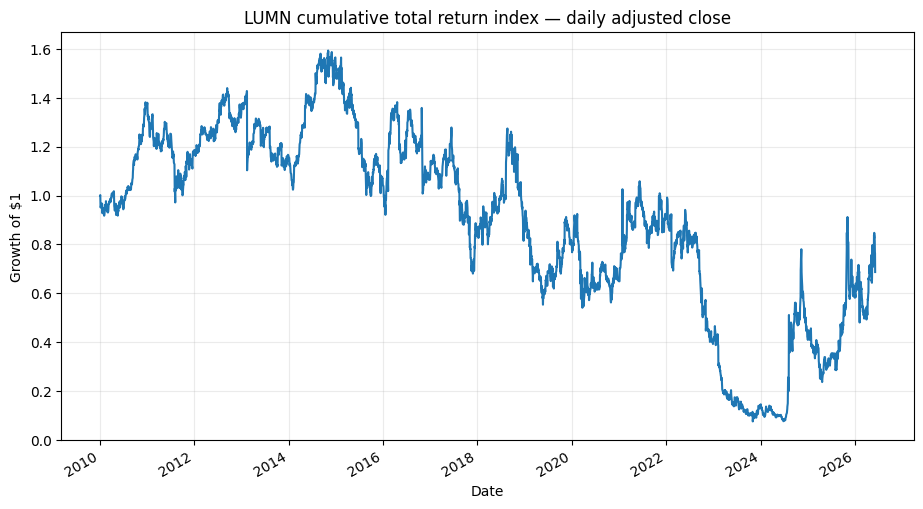

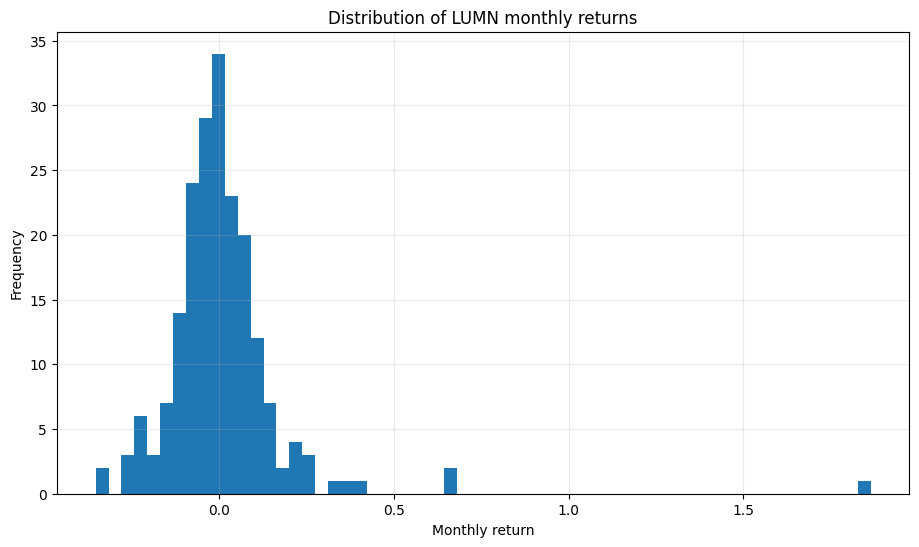

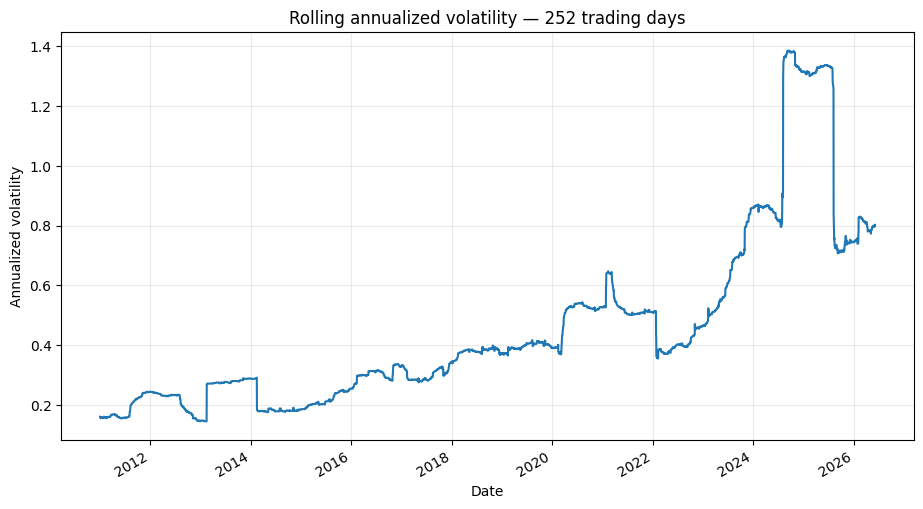

In [7]:

fig, ax = plt.subplots()
(cum_d / cum_d.iloc[0]).plot(ax=ax)
ax.set_title('LUMN cumulative total return index — daily adjusted close')
ax.set_ylabel('Growth of $1')
ax.set_xlabel('Date')
plt.show()

fig, ax = plt.subplots()
ret_m.plot(kind='hist', bins=60, ax=ax)
ax.set_title('Distribution of LUMN monthly returns')
ax.set_xlabel('Monthly return')
plt.show()

fig, ax = plt.subplots()
(ret_d.rolling(252).std() * np.sqrt(252)).plot(ax=ax)
ax.set_title('Rolling annualized volatility — 252 trading days')
ax.set_ylabel('Annualized volatility')
plt.show()



## 5. Construct TTM fundamentals and ratio panel

The statements are quarterly. For income-statement flow variables, the notebook uses trailing-four-quarter sums. For balance-sheet stock variables, it uses quarter-end values and averages where appropriate.

Because no separate cash-flow statement was provided, **free cash flow is modeled as a proxy**:

\[
\text{FCF proxy} = \text{EBITDA} - \text{Cash Taxes} - \text{Cash Interest} - \text{Maintenance Capex} - \text{Growth Reinvestment}.
\]

By default, maintenance capex is set equal to depreciation and growth reinvestment is set to zero. These assumptions are intentionally placed in the `ASSUMPTIONS` dictionary.


In [8]:

# Helper to get a column if it exists.
def col(df, name):
    return df[name] if name in df.columns else pd.Series(index=df.index, dtype=float)

# TTM income-statement items
flows = financials_q.sort_index().copy()
ttm = flows.rolling(4, min_periods=4).sum()

# Balance-sheet stocks, aligned to financial quarter dates
bs = balance_q.sort_index().copy()
all_dates = sorted(set(ttm.index).intersection(bs.index))
ttm = ttm.loc[all_dates]
bs = bs.loc[all_dates]
bs_avg = bs.rolling(4, min_periods=2).mean().loc[all_dates]

# Price and shares aligned to quarters
quarter_prices = prices_d['Adj Close'].resample('Q').last()
quarter_prices.index = quarter_prices.index.to_period('Q').to_timestamp('Q')
# map statement quarter ends to calendar quarter ends
price_aligned = pd.Series(index=ttm.index, dtype=float)
for d in ttm.index:
    qend = d.to_period('Q').to_timestamp('Q')
    price_aligned.loc[d] = quarter_prices.reindex(quarter_prices.index.union([qend])).sort_index().ffill().loc[qend]

basic_shares = col(ttm, 'Basic Average Shares')
diluted_shares = col(ttm, 'Diluted Average Shares')
shares = diluted_shares.where(diluted_shares.notna(), basic_shares)
if ASSUMPTIONS['shares_outstanding_override'] is not None:
    shares = pd.Series(ASSUMPTIONS['shares_outstanding_override'], index=ttm.index)
market_cap = price_aligned * shares

# Main fundamental inputs
revenue = col(ttm, 'Total Revenue')
gross_profit = col(ttm, 'Gross Profit')
op_income = col(ttm, 'Operating Income')
ebit = col(ttm, 'EBIT')
ebitda = col(ttm, 'EBITDA')
net_income = col(ttm, 'Net Income Common Stockholders')
normalized_income = col(ttm, 'Normalized Income')
interest_expense = col(ttm, 'Interest Expense').abs().where(col(ttm, 'Interest Expense').notna(), col(ttm, 'Interest Expense Non Operating').abs())
tax_provision = col(ttm, 'Tax Provision')
dep = col(ttm, 'Reconciled Depreciation').where(col(ttm, 'Reconciled Depreciation').notna(), col(ttm, 'Depreciation').abs())

assets = col(bs, 'Total Assets')
avg_assets = col(bs_avg, 'Total Assets')
current_assets = col(bs, 'Current Assets')
cash = col(bs, 'Cash, Cash Equivalents & Short Term Investments')
receivables = col(bs, 'Receivables')
inventory = col(bs, 'Inventory')
current_liab = col(bs, 'Current Liabilities')
total_liab = col(bs, 'Total Liabilities Net Minority Interest')
current_debt = col(bs, 'Current Debt And Capital Lease Obligation')
long_debt = col(bs, 'Long Term Debt And Capital Lease Obligation')
total_debt = current_debt.fillna(0) + long_debt.fillna(0)
book_equity = col(bs, 'Common Stock Equity').where(col(bs, 'Common Stock Equity').notna(), col(bs, "Stockholders' Equity"))
avg_equity = col(bs_avg, 'Common Stock Equity').where(col(bs_avg, 'Common Stock Equity').notna(), col(bs_avg, "Stockholders' Equity"))
net_debt = total_debt - cash
enterprise_value = market_cap + net_debt + ASSUMPTIONS['preferred_stock_value']

# Cash-flow proxy
cash_tax = tax_provision.clip(lower=0)
maint_capex = dep.abs() * ASSUMPTIONS['maintenance_capex_pct_of_depreciation']
growth_reinvestment = revenue.abs() * ASSUMPTIONS['growth_reinvestment_ratio']
fcf_proxy = ebitda - cash_tax - interest_expense.fillna(0) - maint_capex.fillna(0) - growth_reinvestment
unlevered_fcf_proxy = ebit * (1 - ASSUMPTIONS['statutory_tax_rate_if_missing']) + dep.abs() - maint_capex.fillna(0) - growth_reinvestment


In [9]:

# Build ratio table. More than 25 ratios are included.
ratios = pd.DataFrame(index=ttm.index)

# Liquidity
ratios['current_ratio'] = current_assets / current_liab
ratios['quick_ratio'] = (cash + receivables) / current_liab
ratios['cash_ratio'] = cash / current_liab
ratios['working_capital'] = current_assets - current_liab
ratios['working_capital_to_assets'] = ratios['working_capital'] / assets
ratios['net_debt_to_cash'] = net_debt / cash

# Asset efficiency
ratios['asset_turnover'] = revenue / avg_assets
ratios['receivables_turnover'] = revenue / col(bs_avg, 'Receivables')
ratios['days_sales_outstanding'] = 365 / ratios['receivables_turnover']
ratios['ppe_turnover'] = revenue / col(bs_avg, 'Net PPE')
ratios['goodwill_intangibles_to_assets'] = col(bs, 'Goodwill And Other Intangible Assets') / assets
ratios['revenue_per_share'] = revenue / shares

# Profitability
ratios['gross_margin'] = gross_profit / revenue
ratios['operating_margin'] = op_income / revenue
ratios['ebit_margin'] = ebit / revenue
ratios['ebitda_margin'] = ebitda / revenue
ratios['net_margin'] = net_income / revenue
ratios['normalized_net_margin'] = normalized_income / revenue
ratios['roa'] = net_income / avg_assets
ratios['roe'] = net_income / avg_equity
ratios['roic_pre_tax_proxy'] = ebit / (total_debt + book_equity - cash)
ratios['fcf_proxy_margin'] = fcf_proxy / revenue

# Leverage / solvency
ratios['debt_to_assets'] = total_debt / assets
ratios['liabilities_to_assets'] = total_liab / assets
ratios['debt_to_equity'] = total_debt / book_equity
ratios['net_debt_to_ebitda'] = net_debt / ebitda
ratios['debt_to_ebitda'] = total_debt / ebitda
ratios['interest_coverage_ebit'] = ebit / interest_expense
ratios['interest_coverage_ebitda'] = ebitda / interest_expense
ratios['equity_multiplier'] = assets / book_equity

# Market valuation
ratios['market_cap'] = market_cap
ratios['enterprise_value'] = enterprise_value
ratios['price_to_sales'] = market_cap / revenue
ratios['price_to_book'] = market_cap / book_equity
ratios['price_to_earnings'] = market_cap / net_income
ratios['ev_to_revenue'] = enterprise_value / revenue
ratios['ev_to_ebitda'] = enterprise_value / ebitda
ratios['ev_to_ebit'] = enterprise_value / ebit
ratios['fcf_yield_proxy'] = fcf_proxy / market_cap
ratios['earnings_yield'] = net_income / market_cap

latest_ratios = ratios.dropna(how='all').iloc[-1].sort_index().to_frame('latest')
print(f'Number of ratio/metric columns: {ratios.shape[1]}')
latest_ratios


Number of ratio/metric columns: 40


,latest
asset_turnover,0.3666
cash_ratio,0.3896
current_ratio,0.9880
days_sales_outstanding,51.5168
debt_to_assets,0.4327
debt_to_ebitda,8.4503
debt_to_equity,-10.0607
earnings_yield,-0.0627
ebit_margin,-0.0934
ebitda_margin,0.1294


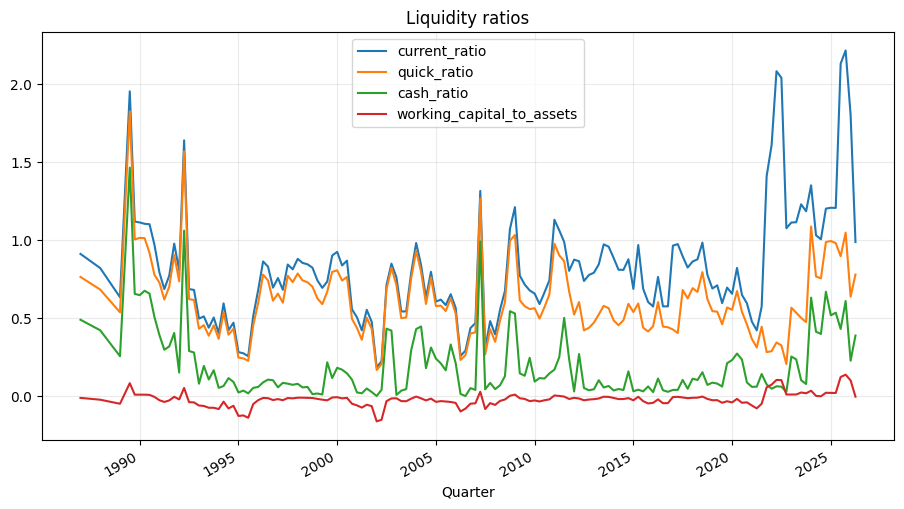

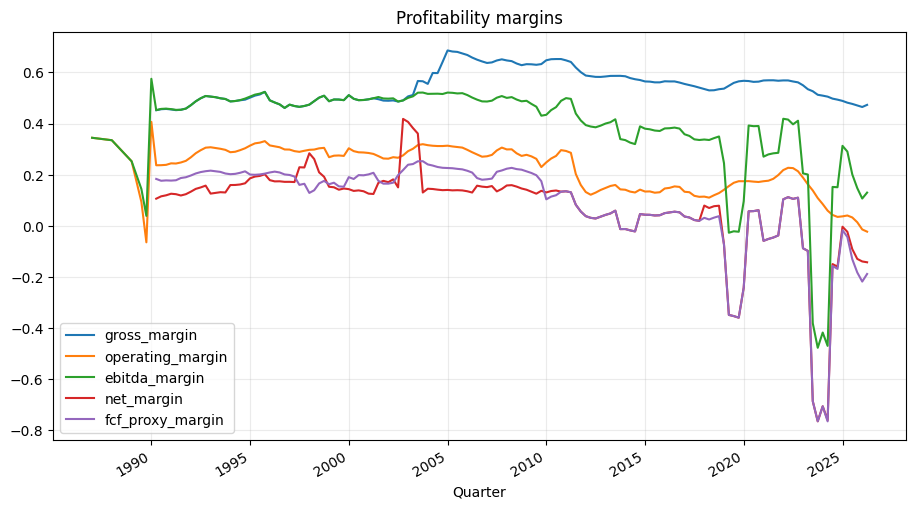

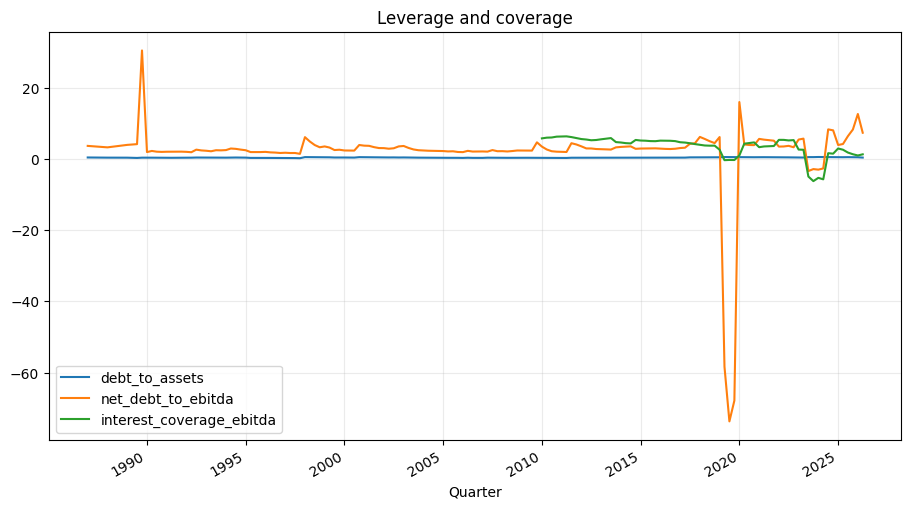

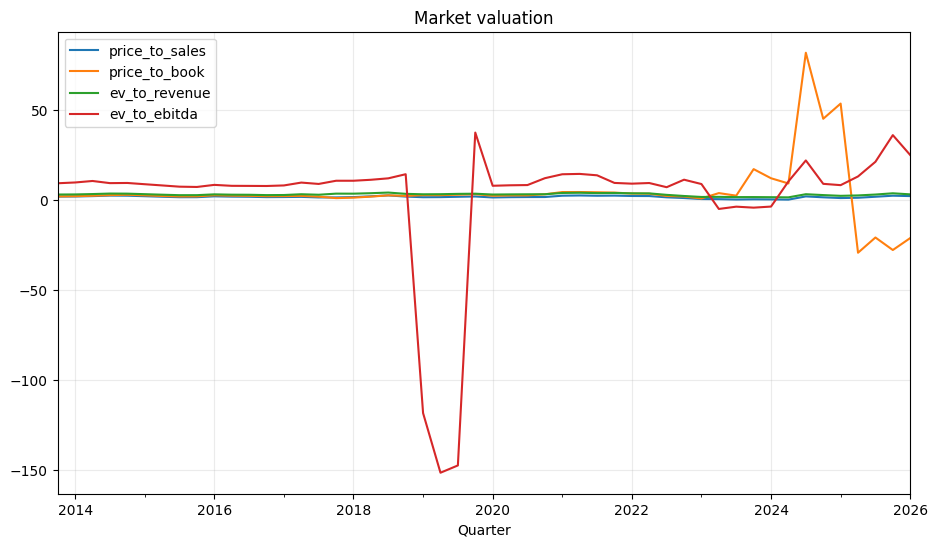

In [10]:

# Plot selected ratios in thematic groups.
plot_groups = {
    'Liquidity ratios': ['current_ratio','quick_ratio','cash_ratio','working_capital_to_assets'],
    'Profitability margins': ['gross_margin','operating_margin','ebitda_margin','net_margin','fcf_proxy_margin'],
    'Leverage and coverage': ['debt_to_assets','net_debt_to_ebitda','interest_coverage_ebitda'],
    'Market valuation': ['price_to_sales','price_to_book','ev_to_revenue','ev_to_ebitda'],
}

for title, cols in plot_groups.items():
    fig, ax = plt.subplots()
    ratios[cols].replace([np.inf, -np.inf], np.nan).dropna(how='all').plot(ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Quarter')
    plt.show()


## 6. Growth rates and financial history

In [11]:

fundamentals = pd.DataFrame({
    'revenue_ttm': revenue,
    'gross_profit_ttm': gross_profit,
    'ebit_ttm': ebit,
    'ebitda_ttm': ebitda,
    'net_income_ttm': net_income,
    'normalized_income_ttm': normalized_income,
    'fcf_proxy_ttm': fcf_proxy,
    'unlevered_fcf_proxy_ttm': unlevered_fcf_proxy,
    'total_assets': assets,
    'total_debt': total_debt,
    'net_debt': net_debt,
    'book_equity': book_equity,
    'shares': shares,
    'market_cap': market_cap,
    'enterprise_value': enterprise_value,
})

growth_qoq = fundamentals.pct_change(1)
growth_yoy = fundamentals.pct_change(4)
growth_3y_cagr = (fundamentals / fundamentals.shift(12)) ** (1/3) - 1

latest_growth = pd.concat({
    'qoq': growth_qoq.iloc[-1],
    'yoy': growth_yoy.iloc[-1],
    '3y_cagr': growth_3y_cagr.iloc[-1]
}, axis=1)
latest_growth


,qoq,yoy,3y_cagr
revenue_ttm,-0.0228,-0.0678,-0.0985
gross_profit_ttm,-0.0054,-0.0845,-0.1344
ebit_ttm,-0.2095,-2.3302,NaN
ebitda_ttm,0.1906,-0.5843,-0.2205
net_income_ttm,-0.0006,4.5527,0.0204
normalized_income_ttm,0.3647,0.9324,NaN
fcf_proxy_ttm,-0.1554,2.9757,0.1193
unlevered_fcf_proxy_ttm,-0.2095,-2.3302,NaN
total_assets,-0.1083,-0.0869,-0.1238
total_debt,-0.2517,-0.2609,-0.1314


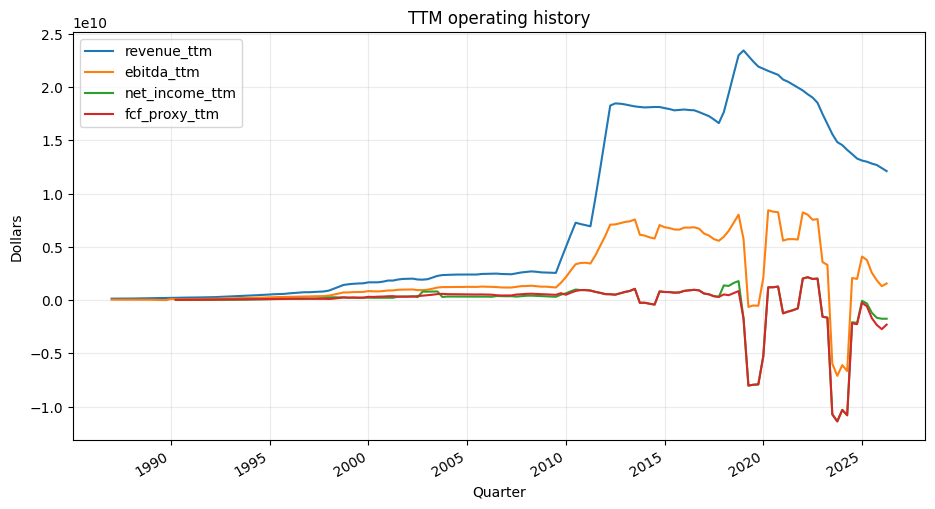

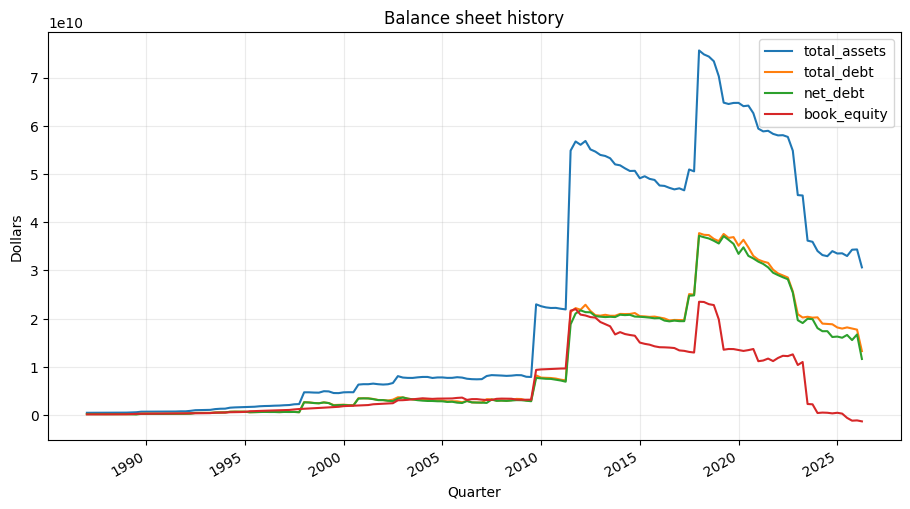

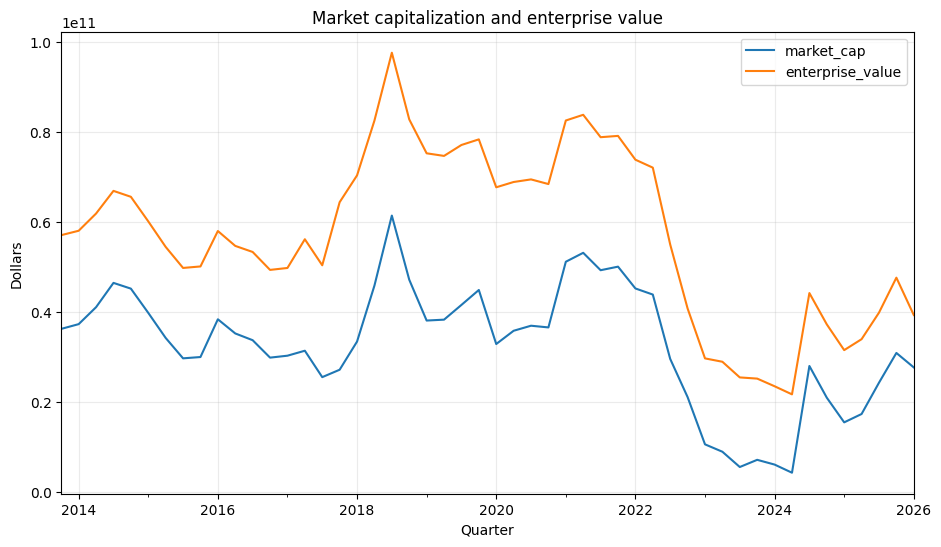

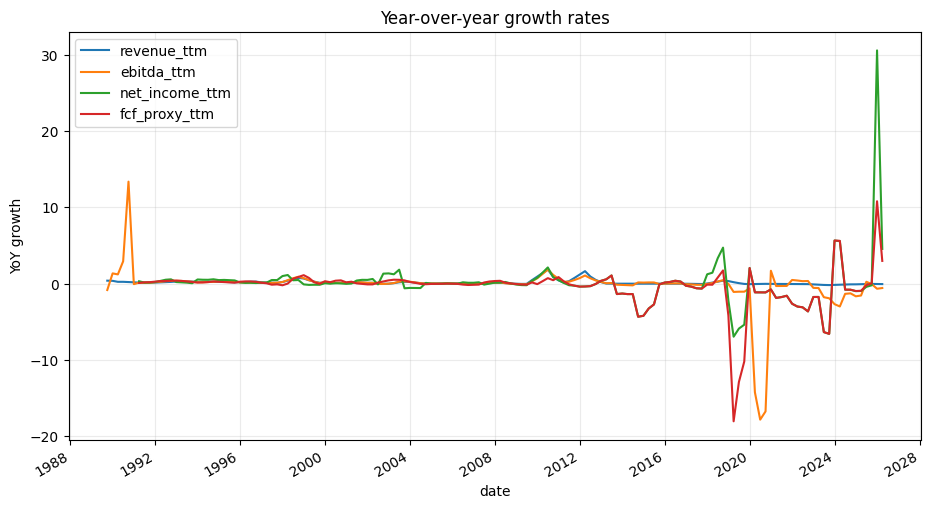

In [12]:

for cols, title in [
    (['revenue_ttm','ebitda_ttm','net_income_ttm','fcf_proxy_ttm'], 'TTM operating history'),
    (['total_assets','total_debt','net_debt','book_equity'], 'Balance sheet history'),
    (['market_cap','enterprise_value'], 'Market capitalization and enterprise value')
]:
    fig, ax = plt.subplots()
    fundamentals[cols].replace([np.inf,-np.inf], np.nan).dropna(how='all').plot(ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Dollars')
    ax.set_xlabel('Quarter')
    plt.show()

fig, ax = plt.subplots()
growth_yoy[['revenue_ttm','ebitda_ttm','net_income_ttm','fcf_proxy_ttm']].replace([np.inf,-np.inf], np.nan).plot(ax=ax)
ax.set_title('Year-over-year growth rates')
ax.set_ylabel('YoY growth')
plt.show()


## 7. Fama-French factor loadings and cost of equity

In [13]:

def align_factor_regression(stock_returns, ff, freq_label):
    # Align by exact dates; monthly files use month-end while price file may use month start. Convert monthly to month-end.
    sr = stock_returns.copy()
    if freq_label == 'monthly':
        sr.index = sr.index.to_period('M').to_timestamp('M')
    # Guard against duplicate dates after calendar alignment.
    sr = sr.groupby(level=0).last()
    ff = ff.groupby(level=0).last()
    common = pd.concat([sr.rename('LUMN'), ff], axis=1, join='inner').dropna()
    factor_cols = [c for c in ff.columns if c != 'RF']
    common['LUMN_excess'] = common['LUMN'] - common.get('RF', 0)
    model, tbl = ols_table(common['LUMN_excess'], common[factor_cols], add_const=True)
    return common, model, tbl

ffm_common, ffm_model, ffm_tbl = align_factor_regression(ret_m, ff_m.loc[ff_m.index >= start], 'monthly')
ffd_common, ffd_model, ffd_tbl = align_factor_regression(ret_d, ff_d.loc[ff_d.index >= start], 'daily')

print('Monthly FF sample:', ffm_common.index.min(), 'to', ffm_common.index.max(), 'n=', len(ffm_common))
print('Daily FF sample:', ffd_common.index.min(), 'to', ffd_common.index.max(), 'n=', len(ffd_common))
print('\nMonthly factor regression:')
display(ffm_tbl)
print('Adj. R2:', None if ffm_model is None else round(ffm_model.rsquared_adj, 4), 'Alpha annualized:', None if ffm_model is None else round(ffm_model.params.get('const', np.nan)*12, 4))
print('\nDaily factor regression:')
display(ffd_tbl)
print('Adj. R2:', None if ffd_model is None else round(ffd_model.rsquared_adj, 4), 'Alpha annualized:', None if ffd_model is None else round(ffd_model.params.get('const', np.nan)*252, 4))


Monthly FF sample: 2010-01-31 00:00:00 to 2026-04-30 00:00:00 n= 196
Daily FF sample: 2010-01-04 00:00:00 to 2026-04-30 00:00:00 n= 4106

Monthly factor regression:


,coef,tstat_HAC,pvalue_HAC
const,0.0012,0.0708,0.9436
Mkt-RF,0.8668,4.0901,0.0000
SMB,1.1681,1.1617,0.2454
HML,0.6837,1.5851,0.1130


Adj. R2: 0.0911 Alpha annualized: 0.0141

Daily factor regression:


,coef,tstat_HAC,pvalue_HAC
const,-0.0001,-0.1810,0.8564
Mkt-RF,0.9722,17.8316,0.0000
SMB,0.4557,4.3105,0.0000
HML,0.4652,6.3933,0.0000


Adj. R2: 0.1312 Alpha annualized: -0.0234


In [14]:

# Cost of equity: use available factor model and sample/override expected factor premia.
# For WACC purposes, use monthly model if available; otherwise daily model.
coeq_model = ffm_model if ffm_model is not None else ffd_model
coeq_common = ffm_common if ffm_model is not None else ffd_common
periods = 12 if ffm_model is not None else 252

if coeq_model is not None:
    rf_ann = ASSUMPTIONS['rf_annual_override']
    if rf_ann is None:
        rf_ann = (1 + coeq_common['RF'].dropna()).prod() ** (periods / len(coeq_common['RF'].dropna())) - 1 if 'RF' in coeq_common else 0.0
    factor_premia_ann = {}
    for f in [c for c in coeq_common.columns if c not in ['LUMN','RF','LUMN_excess']]:
        prem = annualize_return(coeq_common[f], periods)
        factor_premia_ann[f] = prem
    if ASSUMPTIONS['market_risk_premium_override'] is not None and 'Mkt-RF' in factor_premia_ann:
        factor_premia_ann['Mkt-RF'] = ASSUMPTIONS['market_risk_premium_override']
    beta_part = sum(coeq_model.params.get(f, 0) * factor_premia_ann.get(f, 0) for f in factor_premia_ann)
    cost_of_equity = rf_ann + beta_part
else:
    rf_ann = np.nan
    factor_premia_ann = {}
    cost_of_equity = np.nan

pd.DataFrame({
    'input': ['risk_free_rate_annual', 'model_expected_factor_component', 'cost_of_equity'],
    'value': [rf_ann, cost_of_equity - rf_ann, cost_of_equity]
})


,input,value
0,risk_free_rate_annual,0.0137
1,model_expected_factor_component,0.0859
2,cost_of_equity,0.0996


## 8. Cost of debt, capital structure, and WACC

In [15]:

# Bond spreadsheet cost of debt. Use a simple average when only a few bonds are available.
if ASSUMPTIONS['pre_tax_cost_of_debt_override'] is not None:
    pre_tax_cost_debt = ASSUMPTIONS['pre_tax_cost_of_debt_override']
elif 'yield_decimal' in bonds.columns and bonds['yield_decimal'].notna().any():
    # If prices exist, weight by clean price as a rough proxy; otherwise equal-weight.
    if 'price_clean' in bonds.columns and bonds['price_clean'].notna().sum() > 1:
        pre_tax_cost_debt = np.average(bonds['yield_decimal'].dropna(), weights=bonds.loc[bonds['yield_decimal'].notna(), 'price_clean'].fillna(100))
    else:
        pre_tax_cost_debt = bonds['yield_decimal'].mean()
else:
    # fallback from interest expense / average debt
    pre_tax_cost_debt = (interest_expense / total_debt.rolling(4, min_periods=2).mean()).dropna().iloc[-1]

# Effective tax rate from latest TTM; clamp to reasonable range.
ebt_latest = col(ttm, 'Pretax Income').dropna().iloc[-1] if 'Pretax Income' in ttm else np.nan
tax_latest = tax_provision.dropna().iloc[-1] if tax_provision.dropna().shape[0] else np.nan
eff_tax = safe_div(tax_latest, ebt_latest)
if pd.isna(eff_tax) or eff_tax < 0:
    eff_tax = ASSUMPTIONS['statutory_tax_rate_if_missing']
eff_tax = min(max(eff_tax, ASSUMPTIONS['tax_rate_floor']), ASSUMPTIONS['tax_rate_ceiling'])
after_tax_cost_debt = pre_tax_cost_debt * (1 - eff_tax)

latest_market_cap = market_cap.dropna().iloc[-1]
latest_total_debt = total_debt.dropna().iloc[-1]
latest_cash = cash.dropna().iloc[-1]
latest_net_debt = net_debt.dropna().iloc[-1]

if ASSUMPTIONS['target_debt_weight_override'] is not None and ASSUMPTIONS['target_equity_weight_override'] is not None:
    wd = ASSUMPTIONS['target_debt_weight_override']
    we = ASSUMPTIONS['target_equity_weight_override']
else:
    capital = latest_total_debt + latest_market_cap + ASSUMPTIONS['preferred_stock_value']
    wd = latest_total_debt / capital if capital else np.nan
    we = latest_market_cap / capital if capital else np.nan

wacc = we * cost_of_equity + wd * after_tax_cost_debt
wacc_table = pd.DataFrame({
    'metric': ['cost_of_equity', 'pre_tax_cost_of_debt', 'effective_tax_rate', 'after_tax_cost_of_debt', 'equity_weight', 'debt_weight', 'WACC'],
    'value': [cost_of_equity, pre_tax_cost_debt, eff_tax, after_tax_cost_debt, we, wd, wacc]
})
wacc_table


,metric,value
0,cost_of_equity,0.0996
1,pre_tax_cost_of_debt,0.0755
2,effective_tax_rate,0.2424
3,after_tax_cost_of_debt,0.0572
4,equity_weight,0.6764
5,debt_weight,0.3236
6,WACC,0.0859


## 9. JKP factor screens: contemporaneous exposure and one-period-ahead predictability

In [16]:

def load_jkp(path):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    df['ret'] = pd.to_numeric(df['ret'], errors='coerce')
    return df

def pivot_jkp(jkp_long, start_date):
    j = jkp_long[jkp_long['date'] >= pd.Timestamp(start_date)].copy()
    piv = j.pivot_table(index='date', columns='name', values='ret', aggfunc='first').sort_index()
    return piv

jkp_m = pivot_jkp(load_jkp(DATA_DIR / '[usa]_[all_themes]_[monthly]_[vw_cap].csv'), ASSUMPTIONS['analysis_start_date'])
jkp_d = pivot_jkp(load_jkp(DATA_DIR / '[usa]_[all_themes]_[daily]_[vw_cap].csv'), ASSUMPTIONS['analysis_start_date'])

# Align monthly LUMN returns to month-end JKP factors.
lumn_m = ret_m.copy()
lumn_m.index = lumn_m.index.to_period('M').to_timestamp('M')
lumn_m = lumn_m.groupby(level=0).last()
jkp_m = jkp_m.groupby(level=0).last()
jkp_d = jkp_d.groupby(level=0).last()
jkp_m_common = pd.concat([lumn_m.rename('LUMN'), jkp_m], axis=1, join='inner').dropna(subset=['LUMN'])

print('Monthly JKP aligned shape:', jkp_m_common.shape)
print('Daily JKP factor panel shape:', jkp_d.shape)
print('Number of monthly JKP factors:', jkp_m.shape[1])


Monthly JKP aligned shape: (192, 14)
Daily JKP factor panel shape: (4024, 13)
Number of monthly JKP factors: 13


In [17]:

# Univariate contemporaneous factor exposure screen.
rows = []
y = jkp_m_common['LUMN']
for f in jkp_m.columns:
    pair = pd.concat([y, jkp_m_common[f]], axis=1).dropna()
    if len(pair) < ASSUMPTIONS['jkp_min_observations']:
        continue
    X = sm.add_constant(pair[f])
    m = sm.OLS(pair['LUMN'], X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    rows.append({
        'factor': f,
        'n': len(pair),
        'beta': m.params.get(f, np.nan),
        'tstat_HAC': m.tvalues.get(f, np.nan),
        'pvalue_HAC': m.pvalues.get(f, np.nan),
        'adj_r2': m.rsquared_adj,
        'corr': pair['LUMN'].corr(pair[f])
    })
exposure_screen = pd.DataFrame(rows).sort_values('adj_r2', ascending=False)
exposure_screen.head(20)


,factor,n,beta,tstat_HAC,pvalue_HAC,adj_r2,corr
8,quality,192,-3.0706,-2.0505,0.0403,0.0626,-0.2598
11,size,192,2.0352,2.3117,0.0208,0.0474,0.2290
4,low_risk,192,-1.1255,-2.5264,0.0115,0.0290,-0.1847
7,profitability,192,-1.5897,-2.3866,0.0170,0.0255,-0.1750
5,momentum,192,-0.9636,-2.0530,0.0401,0.0106,-0.1257
2,investment,192,0.9693,1.1424,0.2533,0.0013,0.0806
12,value,192,0.4538,0.7266,0.4675,-0.0013,0.0631
3,low_leverage,192,-0.4334,-0.4572,0.6475,-0.0028,-0.0496
1,debt_issuance,192,-1.3362,-0.5777,0.5635,-0.0033,-0.0447
10,short_term_reversal,192,-0.6270,-0.3122,0.7549,-0.0039,-0.0367


In [18]:

# One-period-ahead predictive screen using lagged JKP factor returns.
lag = ASSUMPTIONS['jkp_lag_periods']
rows = []
y_future = jkp_m_common['LUMN']
for f in jkp_m.columns:
    x_lag = jkp_m_common[f].shift(lag)
    pair = pd.concat([y_future, x_lag.rename(f)], axis=1).dropna()
    if len(pair) < ASSUMPTIONS['jkp_min_observations']:
        continue
    X = sm.add_constant(pair[f])
    m = sm.OLS(pair['LUMN'], X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    rows.append({
        'factor': f,
        'n': len(pair),
        'lag_beta': m.params.get(f, np.nan),
        'tstat_HAC': m.tvalues.get(f, np.nan),
        'pvalue_HAC': m.pvalues.get(f, np.nan),
        'adj_r2': m.rsquared_adj,
        'corr': pair['LUMN'].corr(pair[f])
    })
predictive_screen = pd.DataFrame(rows).sort_values('adj_r2', ascending=False)
predictive_screen.head(20)


,factor,n,lag_beta,tstat_HAC,pvalue_HAC,adj_r2,corr
10,short_term_reversal,191,2.8038,1.8922,0.0585,0.0218,0.1643
1,debt_issuance,191,4.9276,1.6974,0.0896,0.0217,0.1639
5,momentum,191,1.0629,2.2953,0.0217,0.0140,0.1385
6,profit_growth,191,2.2926,1.3596,0.1740,0.0075,0.1129
12,value,191,-0.6641,-1.5074,0.1317,0.0033,-0.0923
4,low_risk,191,0.4387,1.2029,0.2290,-0.0001,0.0720
3,low_leverage,191,0.5351,0.9022,0.3670,-0.0015,0.0613
8,quality,191,0.5027,0.7877,0.4309,-0.0035,0.0425
0,accruals,191,0.7480,0.8922,0.3723,-0.0040,0.0357
9,seasonality,191,0.7409,0.3253,0.7449,-0.0049,0.0190


In [19]:

# Multivariate regularized screen using the strongest univariate predictors.
# This is not causal. It is a stability-oriented data-reduction exercise.
top_predictors = predictive_screen.head(ASSUMPTIONS['jkp_max_factors_for_multivariate'])['factor'].tolist()
X_all = jkp_m_common[top_predictors].shift(lag)
y_all = jkp_m_common['LUMN']
ml_data = pd.concat([y_all.rename('y'), X_all], axis=1).dropna()

if len(ml_data) >= 60 and len(top_predictors) > 3:
    X = ml_data.drop(columns=['y'])
    y = ml_data['y']
    tscv = TimeSeriesSplit(n_splits=5)
    models = {
        'LassoCV': Pipeline([('scaler', StandardScaler()), ('model', LassoCV(cv=tscv, random_state=0, max_iter=20000))]),
        'RidgeCV': Pipeline([('scaler', StandardScaler()), ('model', RidgeCV(alphas=np.logspace(-4, 4, 50), cv=tscv))]),
        'ElasticNetCV': Pipeline([('scaler', StandardScaler()), ('model', ElasticNetCV(cv=tscv, random_state=0, max_iter=20000, l1_ratio=[.1,.3,.5,.7,.9]))])
    }
    ml_rows = []
    coefs = {}
    for name, pipe in models.items():
        pipe.fit(X, y)
        pred = pipe.predict(X)
        ml_rows.append({'model': name, 'in_sample_r2': r2_score(y, pred), 'rmse': np.sqrt(mean_squared_error(y, pred))})
        coef = pipe.named_steps['model'].coef_
        coefs[name] = pd.Series(coef, index=X.columns).sort_values(key=np.abs, ascending=False)
    ml_summary = pd.DataFrame(ml_rows).sort_values('in_sample_r2', ascending=False)
    display(ml_summary)
    print('Top nonzero/large ElasticNet coefficients:')
    display(coefs['ElasticNetCV'].loc[lambda s: s.abs() > 1e-8].head(25).to_frame('coef'))
else:
    print('Not enough data for multivariate regularized JKP screen.')


,model,in_sample_r2,rmse
0,LassoCV,0.0892,0.1796
2,ElasticNetCV,0.0892,0.1796
1,RidgeCV,0.0597,0.1825


Top nonzero/large ElasticNet coefficients:


,coef
short_term_reversal,0.0276
debt_issuance,0.0269
value,-0.0137
momentum,0.0132
low_risk,0.0099
accruals,0.0040


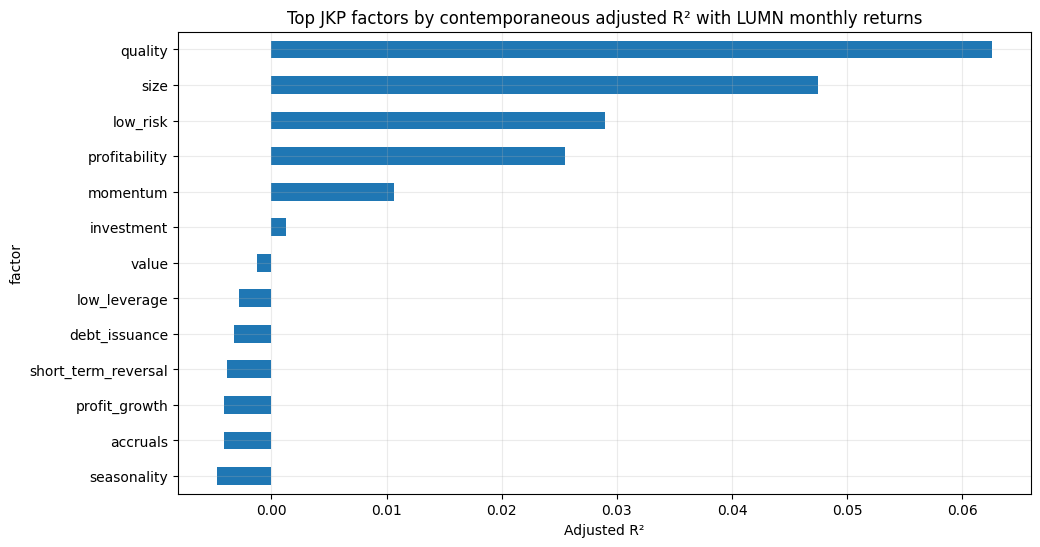

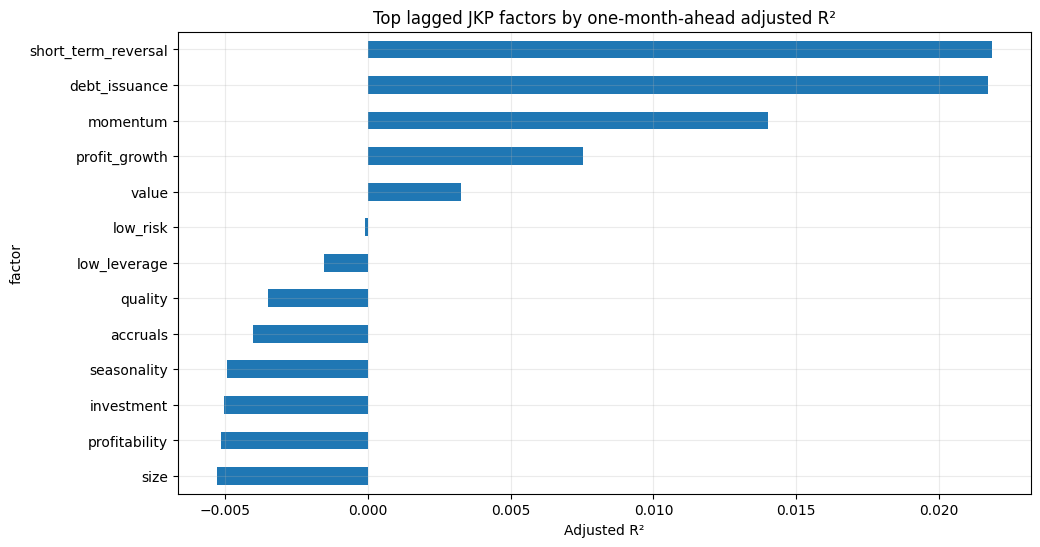

In [20]:

# Visualize top JKP contemporaneous and predictive factors.
fig, ax = plt.subplots()
exposure_screen.head(20).sort_values('adj_r2').plot(kind='barh', x='factor', y='adj_r2', ax=ax, legend=False)
ax.set_title('Top JKP factors by contemporaneous adjusted R² with LUMN monthly returns')
ax.set_xlabel('Adjusted R²')
plt.show()

fig, ax = plt.subplots()
predictive_screen.head(20).sort_values('adj_r2').plot(kind='barh', x='factor', y='adj_r2', ax=ax, legend=False)
ax.set_title('Top lagged JKP factors by one-month-ahead adjusted R²')
ax.set_xlabel('Adjusted R²')
plt.show()



## 10. Valuation analysis

LUMN has had negative earnings in parts of the sample, so a single P/E model is not reliable. This notebook therefore reports several valuation perspectives:

1. **Market multiple snapshot:** EV/Sales, EV/EBITDA, P/S, and P/B.
2. **FCF yield proxy:** useful but highly assumption-sensitive because no cash-flow statement was provided.
3. **Scenario DCF using an operating cash-flow proxy:** revenue growth, EBITDA margin, maintenance capex, terminal growth, and WACC are explicit assumptions.
4. **Exit multiple sensitivity:** terminal EV based on EBITDA multiples.

The point is not to pretend the DCF is precise. The point is to identify what would have to be true for the current equity price to be attractive.


In [21]:

def latest_valid(s):
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan).dropna()
    return s.iloc[-1] if len(s) else np.nan

latest = {
    'revenue': latest_valid(revenue),
    'ebitda': latest_valid(ebitda),
    'ebit': latest_valid(ebit),
    'net_income': latest_valid(net_income),
    'fcf_proxy': latest_valid(fcf_proxy),
    'depreciation': latest_valid(dep),
    'interest_expense': latest_valid(interest_expense),
    'cash_tax': latest_valid(cash_tax),
    'net_debt': latest_valid(net_debt),
    'market_cap': latest_valid(market_cap),
    'shares': latest_valid(shares),
    'price': latest_valid(price_aligned),
}
latest


{'revenue': np.float64(12119000000.0),
 'ebitda': np.float64(1568000000.0),
 'ebit': np.float64(-1132000000.0),
 'net_income': np.float64(-1738000000.0),
 'fcf_proxy': np.float64(-2294000000.0),
 'depreciation': np.float64(2700000000.0),
 'interest_expense': np.float64(1162000000.0),
 'cash_tax': np.float64(0.0),
 'net_debt': np.float64(11625000000.0),
 'market_cap': np.float64(27701407300.0),
 'shares': np.float64(3985814000.0),
 'price': np.float64(6.95)}

In [22]:

def dcf_scenario(assumptions):
    years = int(assumptions['forecast_years'])
    rev0 = latest['revenue']
    ebitda_margin0 = latest['ebitda'] / latest['revenue'] if assumptions['ebitda_margin_start'] is None else assumptions['ebitda_margin_start']
    dep_pct_sales = latest['depreciation'] / latest['revenue'] if latest['revenue'] else np.nan
    interest = latest['interest_expense']
    tax_rate = eff_tax
    g0 = assumptions['revenue_growth_start']
    gT = assumptions['revenue_growth_terminal_approach']
    mT = assumptions['ebitda_margin_terminal']
    tg = assumptions['terminal_growth_rate']
    discount = wacc
    rows = []
    rev = rev0
    for yr in range(1, years + 1):
        g = g0 + (gT - g0) * (yr - 1) / max(years - 1, 1)
        margin = ebitda_margin0 + (mT - ebitda_margin0) * (yr - 1) / max(years - 1, 1)
        rev = rev * (1 + g)
        ebitda_y = rev * margin
        dep_y = rev * dep_pct_sales
        maint_capex_y = dep_y * assumptions['maintenance_capex_pct_of_depreciation']
        growth_reinv_y = abs(rev) * assumptions['growth_reinvestment_ratio']
        ebit_y = ebitda_y - dep_y
        nopat_y = ebit_y * (1 - tax_rate)
        ufcf_y = nopat_y + dep_y - maint_capex_y - growth_reinv_y
        pv_y = ufcf_y / ((1 + discount) ** yr)
        rows.append({'year': yr, 'revenue': rev, 'growth': g, 'ebitda_margin': margin, 'EBITDA': ebitda_y, 'EBIT': ebit_y, 'UFCF_proxy': ufcf_y, 'PV_UFCF': pv_y})
    forecast = pd.DataFrame(rows).set_index('year')
    terminal_fcf = forecast['UFCF_proxy'].iloc[-1] * (1 + tg)
    terminal_value = terminal_fcf / max(discount - tg, 1e-6)
    pv_terminal = terminal_value / ((1 + discount) ** years)
    enterprise_value_dcf = forecast['PV_UFCF'].sum() + pv_terminal
    equity_value = enterprise_value_dcf - latest['net_debt'] * assumptions['net_debt_haircut']
    value_per_share = equity_value / latest['shares']
    return forecast, {
        'PV explicit UFCF': forecast['PV_UFCF'].sum(),
        'PV terminal value': pv_terminal,
        'DCF enterprise value': enterprise_value_dcf,
        'Net debt deducted': latest['net_debt'] * assumptions['net_debt_haircut'],
        'DCF equity value': equity_value,
        'DCF value per share': value_per_share,
        'Latest price': latest['price'],
        'Implied upside/downside': value_per_share / latest['price'] - 1
    }

forecast, dcf_result = dcf_scenario(ASSUMPTIONS)
display(forecast)
pd.Series(dcf_result).to_frame('base_case')


,revenue,growth,ebitda_margin,EBITDA,EBIT,UFCF_proxy,PV_UFCF
year,,,,,,,
1,"11,755,430,000.0000",-0.0300,0.1294,"1,520,960,000.0000","-1,098,040,000.0000","-831,906,503.9233","-766,096,590.3066"
2,"11,451,748,058.3333",-0.0258,0.1612,"1,845,483,674.2222","-705,858,825.7778","-534,778,831.3870","-453,515,596.7483"
3,"11,203,626,850.4028",-0.0217,0.1929,"2,161,430,674.1170","-334,632,738.3830","-253,527,331.8699","-197,993,902.2284"
4,"11,007,563,380.5207",-0.0175,0.2247,"2,473,309,298.4317","20,926,995.6504","15,854,890.3402","11,402,479.0134"
5,"10,860,795,868.7805",-0.0133,0.2565,"2,785,372,786.7494","365,688,914.6719","277,056,379.1193","183,490,338.9100"
6,"10,761,238,573.3166",-0.0092,0.2882,"3,101,718,273.1661","704,214,836.5826","533,533,298.1607","325,398,530.7739"
7,"10,707,432,380.4500",-0.0050,0.3200,"3,426,378,361.7440","1,040,862,442.3435","788,587,151.1739","442,907,225.0196"


,base_case
PV explicit UFCF,"-454,407,515.5664"
PV terminal value,"5,155,905,793.8571"
DCF enterprise value,"4,701,498,278.2907"
Net debt deducted,"11,625,000,000.0000"
DCF equity value,"-6,923,501,721.7093"
DCF value per share,-1.7370
Latest price,6.9500
Implied upside/downside,-1.2499


In [23]:

# Sensitivity table: terminal growth vs WACC using base operating assumptions.
wacc_grid = np.arange(max(0.04, wacc - 0.04), wacc + 0.041, 0.01)
tg_grid = np.array([-0.02, -0.01, 0.00, 0.01, 0.02])
sens = pd.DataFrame(index=[f'{g:.0%}' for g in tg_grid], columns=[f'{x:.1%}' for x in wacc_grid], dtype=float)
for tg in tg_grid:
    for ww in wacc_grid:
        a = ASSUMPTIONS.copy()
        a['terminal_growth_rate'] = tg
        old_wacc = wacc
        # Local DCF variant with temporary global discount replacement
        discount = ww
        years = int(a['forecast_years'])
        rev0 = latest['revenue']
        ebitda_margin0 = latest['ebitda'] / latest['revenue'] if a['ebitda_margin_start'] is None else a['ebitda_margin_start']
        dep_pct_sales = latest['depreciation'] / latest['revenue'] if latest['revenue'] else np.nan
        rev = rev0
        pv = 0
        ufcf_last = np.nan
        for yr in range(1, years+1):
            g = a['revenue_growth_start'] + (a['revenue_growth_terminal_approach'] - a['revenue_growth_start']) * (yr-1) / max(years-1, 1)
            margin = ebitda_margin0 + (a['ebitda_margin_terminal'] - ebitda_margin0) * (yr-1) / max(years-1, 1)
            rev *= (1 + g)
            ebitda_y = rev * margin
            dep_y = rev * dep_pct_sales
            ebit_y = ebitda_y - dep_y
            ufcf_last = ebit_y * (1 - eff_tax) + dep_y - dep_y * a['maintenance_capex_pct_of_depreciation'] - abs(rev) * a['growth_reinvestment_ratio']
            pv += ufcf_last / ((1 + discount) ** yr)
        tv = ufcf_last * (1 + tg) / max(discount - tg, 1e-6)
        ev = pv + tv / ((1 + discount) ** years)
        eq = ev - latest['net_debt'] * a['net_debt_haircut']
        sens.loc[f'{tg:.0%}', f'{ww:.1%}'] = eq / latest['shares']

sens


,4.6%,5.6%,6.6%,7.6%,8.6%,9.6%,10.6%,11.6%,12.6%
-2%,-0.8399,-1.2551,-1.5677,-1.8100,-2.0023,-2.1577,-2.2852,-2.3911,-2.4801
-1%,-0.4296,-0.9698,-1.3608,-1.6552,-1.8835,-2.0647,-2.2111,-2.3313,-2.4311
0%,0.1594,-0.5823,-1.0911,-1.4596,-1.7370,-1.9522,-2.1230,-2.2610,-2.3744
1%,1.0765,-0.0260,-0.7250,-1.2046,-1.5520,-1.8136,-2.0165,-2.1776,-2.3078
2%,2.7017,0.8402,-0.1992,-0.8584,-1.3107,-1.6384,-1.8852,-2.0767,-2.2287


In [24]:

# Exit multiple sensitivity on terminal EBITDA.
mults = ASSUMPTIONS['fcf_multiple_range']
exit_sens = []
for multiple in mults:
    terminal_ev = forecast['EBITDA'].iloc[-1] * multiple
    pv_terminal = terminal_ev / ((1 + wacc) ** ASSUMPTIONS['forecast_years'])
    ev = forecast['PV_UFCF'].sum() + pv_terminal
    eq = ev - latest['net_debt'] * ASSUMPTIONS['net_debt_haircut']
    exit_sens.append({'terminal_EBITDA_multiple': multiple, 'equity_value_per_share': eq / latest['shares'], 'upside_downside': eq / latest['shares'] / latest['price'] - 1})
exit_sens = pd.DataFrame(exit_sens)
exit_sens


,terminal_EBITDA_multiple,equity_value_per_share,upside_downside
0,4,-1.0993,-1.1582
1,5,-0.6165,-1.0887
2,6,-0.1337,-1.0192
3,7,0.3491,-0.9498
4,8,0.8319,-0.8803



## 11. Diagnostic summary

This section converts the quantitative results above into a concise diagnostic checklist. It is deliberately phrased as a starting point for investment research rather than a recommendation.


In [25]:

def fmt_pct(x):
    return 'n/a' if pd.isna(x) else f'{x:.1%}'
def fmt_num(x):
    return 'n/a' if pd.isna(x) else f'{x:,.2f}'
def fmt_dol(x):
    return 'n/a' if pd.isna(x) else f'${x:,.2f}'

summary_points = [
    f"Latest TTM revenue: {fmt_dol(latest['revenue'])}; latest TTM EBITDA: {fmt_dol(latest['ebitda'])}; latest TTM net income: {fmt_dol(latest['net_income'])}.",
    f"Latest market cap: {fmt_dol(latest['market_cap'])}; latest net debt: {fmt_dol(latest['net_debt'])}; latest enterprise value: {fmt_dol(latest_valid(enterprise_value))}.",
    f"Latest EV/Revenue: {fmt_num(latest_valid(ratios['ev_to_revenue']))}; EV/EBITDA: {fmt_num(latest_valid(ratios['ev_to_ebitda']))}; P/B: {fmt_num(latest_valid(ratios['price_to_book']))}.",
    f"Cost of equity estimate: {fmt_pct(cost_of_equity)}; after-tax cost of debt: {fmt_pct(after_tax_cost_debt)}; WACC: {fmt_pct(wacc)}.",
    f"Base-case DCF value per share: {fmt_dol(dcf_result['DCF value per share'])}; latest price in file: {fmt_dol(latest['price'])}; implied upside/downside: {fmt_pct(dcf_result['Implied upside/downside'])}.",
    f"Daily annualized return since {ASSUMPTIONS['analysis_start_date']}: {fmt_pct(summary_returns.loc['ann_return_CAGR','daily_sample'])}; annualized volatility: {fmt_pct(summary_returns.loc['ann_vol','daily_sample'])}; max drawdown: {fmt_pct(summary_returns.loc['max_drawdown','daily_sample'])}.",
]
for s in summary_points:
    print('• ' + s)


• Latest TTM revenue: $12,119,000,000.00; latest TTM EBITDA: $1,568,000,000.00; latest TTM net income: $-1,738,000,000.00.
• Latest market cap: $27,701,407,300.00; latest net debt: $11,625,000,000.00; latest enterprise value: $39,326,407,300.00.
• Latest EV/Revenue: 3.25; EV/EBITDA: 25.08; P/B: -21.03.
• Cost of equity estimate: 10.0%; after-tax cost of debt: 5.7%; WACC: 8.6%.
• Base-case DCF value per share: $-1.74; latest price in file: $6.95; implied upside/downside: -125.0%.
• Daily annualized return since 2010-01-01: -2.2%; annualized volatility: 54.7%; max drawdown: -95.3%.



## 12. Interpretation template

Use the following template after reviewing the tables and figures above.

- **Liquidity:** focus on current ratio, quick ratio, cash ratio, working capital/assets, and near-term debt maturities.
- **Efficiency:** evaluate whether revenue/assets and revenue/PPE are stabilizing or deteriorating.
- **Profitability:** distinguish accounting losses from operating cash-flow capacity. Goodwill/intangible impairments can make GAAP earnings noisy.
- **Leverage:** net debt/EBITDA and interest coverage are central for a capital-intensive telecom/infrastructure business.
- **Market valuation:** EV/Revenue and EV/EBITDA are often more informative than P/E when earnings are negative.
- **Factor risk:** compare market beta, size/value exposure, FF alpha, JKP contemporaneous factor exposures, and lagged JKP predictors. Treat predictive screens as hypotheses, not as causal evidence.
- **Valuation:** the scenario DCF should be interpreted as a break-even map: what revenue trend, margin recovery, WACC, and terminal assumptions are needed to justify the market price?

When peer financials are added, the next notebook revision should compare LUMN against similarly leveraged telecom and communications-infrastructure firms on EV/EBITDA, net debt/EBITDA, interest coverage, EBITDA margin, revenue growth, FCF yield, and factor exposures.


<!-- EXPANDED_PEERS_FF5_153_START -->

## 13. Expanded inputs: FF5 daily/monthly files, 153-factor monthly JKP file, and peer ZIP

This extension preserves the original single-company analysis above and adds three layers requested for the revised notebook:

1. Fama-French **five-factor** regressions using the newly supplied monthly and daily files.
2. A broader **153-factor** JKP-style monthly factor screen using the supplied `[usa]_[all_factors]...` file.
3. Peer comparisons using the peer income statements, balance sheets, and historical share prices. DTEGY and VOD accounting statements are treated as EUR-denominated and converted to USD using an explicit, editable EUR/USD assumption for cross-company scale comparisons. Ratio comparisons that are currency-invariant are unaffected by this conversion.

The goal is not to overwrite the earlier analysis but to make the notebook more comprehensive and easier to update when peer data or factor files change.


In [26]:

# -----------------------------
# Expanded analysis assumptions and paths
# -----------------------------
EXPANDED_ASSUMPTIONS = {
    # Currency conversion for accounting statement values, used only for cross-peer scale comparisons.
    # DTEGY and VOD accounting data are in EUR; prices in the CSVs are ADR/share-price data in USD.
    # Currency-invariant ratios such as margin, ROA, ROE, leverage, and turnover do not depend on this setting.
    'eurusd_accounting_translation_rate': 1.08,
    'peer_price_start_date': ASSUMPTIONS.get('analysis_start_date', '2010-01-01'),
    'peer_recent_years_for_return_stats': 5,
    'ff5_cost_of_equity_use_monthly': True,
    'jkp153_min_observations': 60,
    'jkp153_top_n_display': 25,
    'jkp153_max_features_for_ml': 60,
    'jkp153_prediction_lag': 1,
    'jkp153_oos_min_train_obs': 60,
}

EXPANDED_ZIP_PATHS = {
    'jkp153_monthly_zip': Path('/mnt/data/[usa]_[all_factors]_[monthly]_[vw_cap]_[factor] (1).zip'),
    'ff5_daily_zip': Path('/mnt/data/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip'),
    'ff5_monthly_zip': Path('/mnt/data/F-F_Research_Data_5_Factors_2x3_CSV (1).zip'),
    'peers_zip': Path('/mnt/data/LUMN_peers.zip'),
}

# If the notebook is run outside this environment, look in the working directory too.
for k, p in list(EXPANDED_ZIP_PATHS.items()):
    if not p.exists():
        candidate = Path.cwd() / p.name
        if candidate.exists():
            EXPANDED_ZIP_PATHS[k] = candidate

for label, p in EXPANDED_ZIP_PATHS.items():
    print(f'{label}: {p} | exists={p.exists()}')


jkp153_monthly_zip: /mnt/data/[usa]_[all_factors]_[monthly]_[vw_cap]_[factor] (1).zip | exists=True
ff5_daily_zip: /mnt/data/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip | exists=True
ff5_monthly_zip: /mnt/data/F-F_Research_Data_5_Factors_2x3_CSV (1).zip | exists=True
peers_zip: /mnt/data/LUMN_peers.zip | exists=True


In [27]:

def read_first_csv_from_zip(zip_path, filename_contains=None, encoding='latin1'):
    """Return (member_name, decoded_text) for the first CSV in a zip file."""
    zip_path = Path(zip_path)
    if not zip_path.exists():
        raise FileNotFoundError(zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        names = [n for n in z.namelist() if n.lower().endswith('.csv')]
        if filename_contains is not None:
            names = [n for n in names if filename_contains.lower() in n.lower()]
        if not names:
            raise FileNotFoundError(f'No matching CSV found in {zip_path}')
        member = names[0]
        text = z.read(member).decode(encoding, errors='ignore')
    return member, text

def load_ken_french_from_zip(zip_path, freq='monthly'):
    """Load zipped Ken French CSVs with header comments and returns in percent."""
    member, text = read_first_csv_from_zip(zip_path)
    lines = text.splitlines()
    header_idx = None
    for i, line in enumerate(lines):
        if line.startswith(',') and ('Mkt-RF' in line or 'Mkt_RF' in line):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f'Could not locate Ken French factor header in {zip_path}')
    data_lines = []
    for line in lines[header_idx:]:
        if line.strip() == '':
            if len(data_lines) > 1:
                break
            continue
        if line.lower().startswith('annual'):
            break
        data_lines.append(line)
    from io import StringIO
    df = pd.read_csv(StringIO('\n'.join(data_lines)))
    first = df.columns[0]
    df = df.rename(columns={first: 'date_code'})
    df = df[pd.to_numeric(df['date_code'], errors='coerce').notna()].copy()
    df['date_code'] = df['date_code'].astype(str).str.strip()
    if freq == 'daily':
        df['date'] = pd.to_datetime(df['date_code'], format='%Y%m%d')
    else:
        df['date'] = pd.to_datetime(df['date_code'], format='%Y%m') + pd.offsets.MonthEnd(0)
    df = df.drop(columns=['date_code']).set_index('date').sort_index()
    df.columns = [c.strip().replace('Mkt_RF', 'Mkt-RF') for c in df.columns]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce') / 100.0
    df.attrs['source_member'] = member
    return df

def load_jkp_long_from_zip(zip_path):
    member, _ = read_first_csv_from_zip(zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        with z.open(member) as f:
            df = pd.read_csv(f)
    df['date'] = pd.to_datetime(df['date'])
    df['ret'] = pd.to_numeric(df['ret'], errors='coerce')
    df['name'] = df['name'].astype(str)
    df.attrs['source_member'] = member
    return df

def p_adjust_bh(pvalues):
    """Benjamini-Hochberg FDR-adjusted p-values."""
    p = pd.Series(pvalues).astype(float)
    out = pd.Series(np.nan, index=p.index, dtype=float)
    valid = p.dropna().sort_values()
    m = len(valid)
    if m == 0:
        return out
    ranks = np.arange(1, m + 1)
    adj = (valid.values * m / ranks)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0, 1)
    out.loc[valid.index] = adj
    return out

def regression_screen(y, X, lag=0, min_obs=60):
    """Univariate OLS screen for many factor columns."""
    rows = []
    y0 = y.copy().rename('target')
    for factor in X.columns:
        x = X[factor].shift(lag) if lag else X[factor]
        data = pd.concat([y0, x.rename(factor)], axis=1).dropna()
        if len(data) < min_obs or data[factor].std() == 0:
            continue
        Xreg = sm.add_constant(data[[factor]])
        model = sm.OLS(data['target'], Xreg).fit(cov_type='HAC', cov_kwds={'maxlags': min(3, max(1, len(data)//20))})
        rows.append({
            'factor': factor,
            'n_obs': len(data),
            'alpha': model.params.get('const', np.nan),
            'beta': model.params.get(factor, np.nan),
            't_beta_HAC': model.tvalues.get(factor, np.nan),
            'p_beta_HAC': model.pvalues.get(factor, np.nan),
            'r2': model.rsquared,
            'adj_r2': model.rsquared_adj,
            'corr': data['target'].corr(data[factor]),
        })
    res = pd.DataFrame(rows)
    if not res.empty:
        res['p_beta_BH'] = p_adjust_bh(res.set_index('factor')['p_beta_HAC']).reindex(res['factor']).values
        res['abs_t'] = res['t_beta_HAC'].abs()
        res['abs_corr'] = res['corr'].abs()
    return res

def time_series_cv_predictions(y, X, model_kind='elastic_net', min_train=60):
    """Simple expanding-window OOS one-step-ahead predictions."""
    data = pd.concat([y.rename('y'), X], axis=1).dropna()
    if len(data) <= min_train + 12:
        return pd.DataFrame(), None
    preds = []
    coefs = []
    alphas = []
    for i in range(min_train, len(data)):
        train = data.iloc[:i]
        test = data.iloc[i:i+1]
        X_train = train.drop(columns='y')
        y_train = train['y']
        X_test = test.drop(columns='y')
        # Small CV grid keeps the notebook fast and stable.
        if model_kind == 'ridge':
            model = Pipeline([('scaler', StandardScaler()), ('model', RidgeCV(alphas=np.logspace(-4, 4, 25)))])
        else:
            model = Pipeline([('scaler', StandardScaler()), ('model', ElasticNetCV(l1_ratio=[0.2, 0.5, 0.8, 1.0], alphas=None, cv=min(5, max(2, len(train)//24)), max_iter=20000, random_state=0))])
        model.fit(X_train, y_train)
        pred = float(model.predict(X_test)[0])
        preds.append({'date': test.index[0], 'actual': float(test['y'].iloc[0]), 'predicted': pred})
        final = model.named_steps['model']
        coef = pd.Series(final.coef_, index=X_train.columns)
        coefs.append(coef.rename(test.index[0]))
        if hasattr(final, 'alpha_'):
            alphas.append(final.alpha_)
    pred_df = pd.DataFrame(preds).set_index('date')
    coef_df = pd.DataFrame(coefs) if coefs else pd.DataFrame()
    metrics = {
        'n_oos': len(pred_df),
        'oos_r2_vs_mean': 1 - ((pred_df['actual'] - pred_df['predicted'])**2).sum() / ((pred_df['actual'] - data['y'].iloc[:min_train].mean())**2).sum(),
        'rmse': np.sqrt(mean_squared_error(pred_df['actual'], pred_df['predicted'])),
        'prediction_actual_corr': pred_df['actual'].corr(pred_df['predicted']),
        'avg_selected_features': float((coef_df.abs() > 1e-10).sum(axis=1).mean()) if not coef_df.empty else np.nan,
        'avg_alpha': float(np.mean(alphas)) if alphas else np.nan,
    }
    return pred_df, {'metrics': metrics, 'coefs': coef_df}


<!-- EXPANDED_PEERS_FF5_153_START -->

## 14. Fama-French five-factor regressions: monthly and daily

The original notebook used the factor files bundled with the first LUMN ZIP. This section loads the newly supplied Fama-French 5-factor files and estimates monthly and daily excess-return regressions:

\[
R_{i,t}-R_{f,t}=lpha+eta_M(MKT_t-RF_t)+eta_S SMB_t+eta_H HML_t+eta_R RMW_t+eta_C CMA_t+\epsilon_t.
\]

The monthly model is preferable for cost-of-equity estimates because it is less dominated by high-frequency microstructure noise. The daily model is still useful for a higher-observation estimate of contemporaneous exposures.


In [28]:

# Load supplied FF5 files.
ff5_m = load_ken_french_from_zip(EXPANDED_ZIP_PATHS['ff5_monthly_zip'], freq='monthly')
ff5_d = load_ken_french_from_zip(EXPANDED_ZIP_PATHS['ff5_daily_zip'], freq='daily')

print('FF5 monthly columns:', list(ff5_m.columns), '| sample:', ff5_m.index.min().date(), 'to', ff5_m.index.max().date())
print('FF5 daily columns:', list(ff5_d.columns), '| sample:', ff5_d.index.min().date(), 'to', ff5_d.index.max().date())

ff5m_common, ff5m_model, ff5m_tbl = align_factor_regression(ret_m, ff5_m.loc[ff5_m.index >= start], 'monthly')
ff5d_common, ff5d_model, ff5d_tbl = align_factor_regression(ret_d, ff5_d.loc[ff5_d.index >= start], 'daily')

print('\nMonthly FF5 regression')
display(ff5m_tbl)
print('Monthly FF5 adjusted R2:', None if ff5m_model is None else round(ff5m_model.rsquared_adj, 4))
print('Monthly FF5 annualized alpha:', None if ff5m_model is None else f"{ff5m_model.params.get('const', np.nan)*12:.2%}")

print('\nDaily FF5 regression')
display(ff5d_tbl)
print('Daily FF5 adjusted R2:', None if ff5d_model is None else round(ff5d_model.rsquared_adj, 4))
print('Daily FF5 annualized alpha:', None if ff5d_model is None else f"{ff5d_model.params.get('const', np.nan)*252:.2%}")

# Factor premia and implied cost of equity.
ff5_factor_cols = [c for c in ff5_m.columns if c != 'RF']
monthly_premia_ann = ff5m_common[ff5_factor_cols].mean() * 12
monthly_rf_ann = ff5m_common['RF'].mean() * 12 if 'RF' in ff5m_common.columns else np.nan
if ASSUMPTIONS.get('rf_annual_override') is not None:
    monthly_rf_ann = ASSUMPTIONS['rf_annual_override']

ff5_beta = ff5m_model.params.reindex(ff5_factor_cols) if ff5m_model is not None else pd.Series(dtype=float)
ff5_cost_of_equity = monthly_rf_ann + (ff5_beta * monthly_premia_ann.reindex(ff5_beta.index)).sum()
ff5_expected_excess = (ff5_beta * monthly_premia_ann.reindex(ff5_beta.index)).sum()

ff5_coe_table = pd.DataFrame({
    'beta_monthly': ff5_beta,
    'sample_factor_premium_annualized': monthly_premia_ann.reindex(ff5_beta.index),
    'contribution_to_cost_of_equity': ff5_beta * monthly_premia_ann.reindex(ff5_beta.index)
})
print('\nFF5 cost-of-equity decomposition using sample annualized factor premia:')
display(ff5_coe_table)
print(f"RF assumption / sample annual RF: {monthly_rf_ann:.2%}")
print(f"FF5 expected excess return: {ff5_expected_excess:.2%}")
print(f"FF5 implied cost of equity: {ff5_cost_of_equity:.2%}")


FF5 monthly columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF'] | sample: 1963-07-31 to 2026-04-30
FF5 daily columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF'] | sample: 1963-07-01 to 2026-04-30

Monthly FF5 regression


,coef,tstat_HAC,pvalue_HAC
const,0.0016,0.0971,0.9226
Mkt-RF,0.8652,3.4846,0.0005
SMB,1.1585,0.9244,0.3553
HML,0.3525,0.8511,0.3947
RMW,-0.3142,-0.3070,0.7588
CMA,0.3203,0.4341,0.6642


Monthly FF5 adjusted R2: 0.0858
Monthly FF5 annualized alpha: 1.95%

Daily FF5 regression


,coef,tstat_HAC,pvalue_HAC
const,-0.0001,-0.2715,0.7860
Mkt-RF,1.0250,19.1155,0.0000
SMB,0.5323,4.9261,0.0000
HML,0.1608,1.3899,0.1645
RMW,0.1564,0.9558,0.3392
CMA,0.5733,2.0603,0.0394


Daily FF5 adjusted R2: 0.135
Daily FF5 annualized alpha: -3.48%

FF5 cost-of-equity decomposition using sample annualized factor premia:


,beta_monthly,sample_factor_premium_annualized,contribution_to_cost_of_equity
Mkt-RF,0.8652,0.1304,0.1128
SMB,1.1585,-0.0094,-0.0109
HML,0.3525,-0.0060,-0.0021
RMW,-0.3142,0.0231,-0.0072
CMA,0.3203,0.0018,0.0006


RF assumption / sample annual RF: 1.36%
FF5 expected excess return: 9.31%
FF5 implied cost of equity: 10.67%


,monthly_beta,daily_beta
Mkt-RF,0.8652,1.0250
SMB,1.1585,0.5323
HML,0.3525,0.1608
RMW,-0.3142,0.1564
CMA,0.3203,0.5733


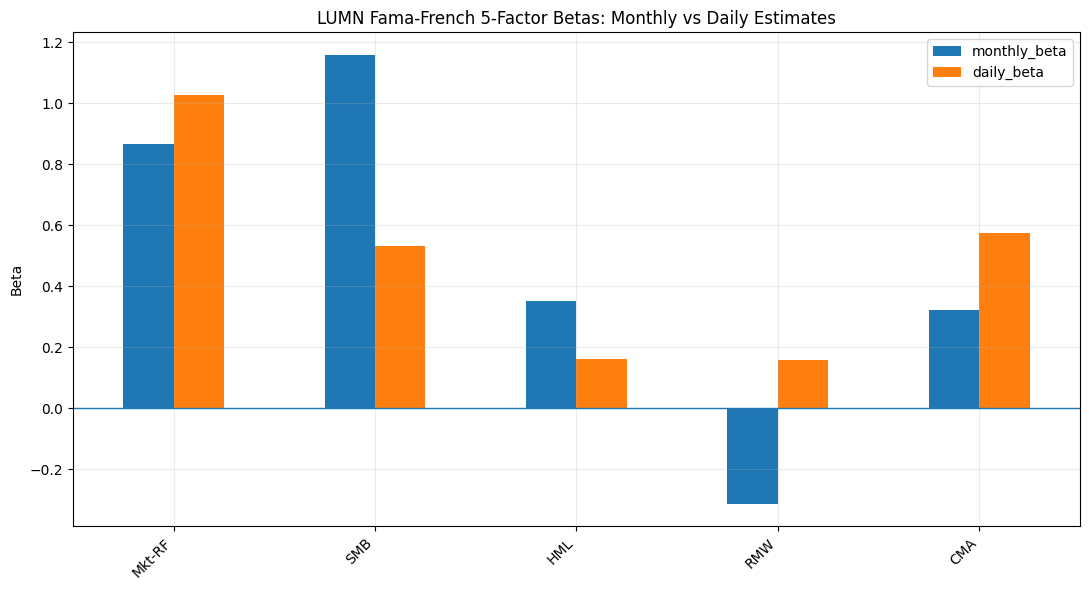

In [29]:

# Compare monthly and daily FF5 betas visually.
if ff5m_model is not None and ff5d_model is not None:
    beta_compare = pd.DataFrame({
        'monthly_beta': ff5m_model.params.drop('const', errors='ignore'),
        'daily_beta': ff5d_model.params.drop('const', errors='ignore')
    }).dropna(how='all')
    display(beta_compare)
    ax = beta_compare.plot(kind='bar')
    ax.set_title('LUMN Fama-French 5-Factor Betas: Monthly vs Daily Estimates')
    ax.axhline(0, linewidth=1)
    ax.set_ylabel('Beta')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


<!-- EXPANDED_PEERS_FF5_153_START -->

## 15. Full 153-factor monthly JKP analysis

This section expands the earlier factor screen to the supplied 153-factor monthly file. It runs:

- contemporaneous exposure regressions of LUMN monthly returns on each factor;
- predictive regressions using lagged factor returns;
- false-discovery-rate adjusted p-values, since 153 tests create a multiple-comparisons problem;
- regularized multivariate forecasting using the strongest univariate predictors; and
- a simple long/cash timing illustration based on out-of-sample predicted LUMN excess returns.

These screens should be interpreted as exploratory. The strongest factors may reveal economic sensitivities, but a single-stock factor screen is noisy and prone to data mining.


In [30]:

jkp153_long = load_jkp_long_from_zip(EXPANDED_ZIP_PATHS['jkp153_monthly_zip'])
jkp153 = jkp153_long.pivot_table(index='date', columns='name', values='ret', aggfunc='first').sort_index()
jkp153 = jkp153.loc[jkp153.index >= pd.Timestamp(ASSUMPTIONS['analysis_start_date'])]

# Align target to month-end. Use LUMN excess returns when FF RF is available.
lumn_m_for_jkp = ret_m.copy()
lumn_m_for_jkp.index = lumn_m_for_jkp.index.to_period('M').to_timestamp('M')
lumn_m_for_jkp = lumn_m_for_jkp.groupby(level=0).last().rename('LUMN')
rf_for_jkp = ff5_m['RF'].reindex(jkp153.index).rename('RF')
lumn_excess_m = (lumn_m_for_jkp - rf_for_jkp.reindex(lumn_m_for_jkp.index)).rename('LUMN_excess')

jkp153_common = pd.concat([lumn_excess_m, jkp153], axis=1, join='inner').dropna(subset=['LUMN_excess'])
jkp153_X = jkp153_common.drop(columns=['LUMN_excess'])
jkp153_y = jkp153_common['LUMN_excess']

print('JKP 153 source member:', jkp153_long.attrs.get('source_member'))
print('Number of factor names:', jkp153_X.shape[1])
print('Aligned sample:', jkp153_common.index.min().date(), 'to', jkp153_common.index.max().date(), '| observations:', len(jkp153_common))

jkp153_contemp = regression_screen(
    jkp153_y, jkp153_X, lag=0,
    min_obs=EXPANDED_ASSUMPTIONS['jkp153_min_observations']
).sort_values(['abs_t', 'adj_r2'], ascending=[False, False])

jkp153_predictive = regression_screen(
    jkp153_y, jkp153_X, lag=EXPANDED_ASSUMPTIONS['jkp153_prediction_lag'],
    min_obs=EXPANDED_ASSUMPTIONS['jkp153_min_observations']
).sort_values(['abs_t', 'adj_r2'], ascending=[False, False])

print('\nTop contemporaneous JKP factor exposures')
display(jkp153_contemp.head(EXPANDED_ASSUMPTIONS['jkp153_top_n_display']))
print('\nTop one-month-ahead predictive JKP factors')
display(jkp153_predictive.head(EXPANDED_ASSUMPTIONS['jkp153_top_n_display']))

# Multiple testing summary.
multitest_summary = pd.DataFrame({
    'screen': ['contemporaneous', 'predictive_lagged'],
    'factors_tested': [len(jkp153_contemp), len(jkp153_predictive)],
    'p<0.05_raw': [(jkp153_contemp['p_beta_HAC'] < 0.05).sum(), (jkp153_predictive['p_beta_HAC'] < 0.05).sum()],
    'BH_q<0.10': [(jkp153_contemp['p_beta_BH'] < 0.10).sum(), (jkp153_predictive['p_beta_BH'] < 0.10).sum()],
    'BH_q<0.05': [(jkp153_contemp['p_beta_BH'] < 0.05).sum(), (jkp153_predictive['p_beta_BH'] < 0.05).sum()],
})
display(multitest_summary)


JKP 153 source member: [usa]_[all_factors]_[monthly]_[vw_cap].csv
Number of factor names: 153
Aligned sample: 2010-01-31 to 2025-12-31 | observations: 192



Top contemporaneous JKP factor exposures


,factor,n_obs,alpha,beta,t_beta_HAC,p_beta_HAC,r2,adj_r2,corr,p_beta_BH,abs_t,abs_corr
107,qmj_safety,192,0.0079,-1.8772,-6.0144,0.0000,0.0631,0.0582,-0.2512,0.0000,6.0144,0.2512
102,prc,192,0.0118,1.5984,4.5589,0.0000,0.0604,0.0555,0.2458,0.0004,4.5589,0.2458
103,prc_highprc_252d,192,0.0117,-0.8231,-4.4349,0.0000,0.0338,0.0287,-0.1837,0.0005,4.4349,0.1837
10,beta_60m,192,0.0073,-0.9253,-3.8077,0.0001,0.0433,0.0383,-0.2082,0.0054,3.8077,0.2082
12,betabab_1260d,192,0.0075,-0.7794,-3.5801,0.0003,0.0364,0.0314,-0.1909,0.0105,3.5801,0.1909
104,qmj,192,0.0122,-2.1841,-3.5091,0.0004,0.0740,0.0691,-0.2720,0.0115,3.5091,0.2720
124,rvol_21d,192,0.0110,-0.8149,-2.8521,0.0043,0.0368,0.0318,-0.1919,0.0788,2.8521,0.1919
60,ivol_capm_21d,192,0.0117,-0.9531,-2.8275,0.0047,0.0371,0.0320,-0.1926,0.0788,2.8275,0.1926
11,beta_dimson_21d,192,0.0076,-0.9541,-2.8025,0.0051,0.0327,0.0276,-0.1809,0.0788,2.8025,0.1809
71,ncol_gr1a,192,0.0108,3.2283,2.7961,0.0052,0.0313,0.0262,0.1768,0.0788,2.7961,0.1768



Top one-month-ahead predictive JKP factors


,factor,n_obs,alpha,beta,t_beta_HAC,p_beta_HAC,r2,adj_r2,corr,p_beta_BH,abs_t,abs_corr
119,ret_9_1,191,0.0061,0.8983,2.6401,0.0083,0.0244,0.0193,0.1563,0.4878,2.6401,0.1563
122,rmax5_rvol_21d,191,0.0056,2.0267,2.5055,0.0122,0.0406,0.0356,0.2016,0.4878,2.5055,0.2016
59,ival_me,191,0.0092,-1.1282,-2.4205,0.0155,0.0212,0.0160,-0.1457,0.4878,2.4205,0.1457
123,rskew_21d,191,0.0078,2.2133,2.3395,0.0193,0.0241,0.0189,0.1551,0.4878,2.3395,0.1551
113,ret_12_1,191,0.0068,0.7434,2.2632,0.0236,0.0172,0.0120,0.1312,0.4878,2.2632,0.1312
111,resff3_12_1,191,0.0078,1.5699,2.1596,0.0308,0.0235,0.0184,0.1534,0.4878,2.1596,0.1534
58,iskew_hxz4_21d,191,0.0087,2.7014,2.0966,0.0360,0.0204,0.0152,0.1427,0.4878,2.0966,0.1427
85,nncoa_gr1a,191,0.0057,1.2056,1.9786,0.0479,0.0090,0.0038,0.0951,0.4878,1.9786,0.0951
87,noa_gr1a,191,0.0053,1.2515,1.9273,0.0539,0.0095,0.0043,0.0977,0.4878,1.9273,0.0977
74,nfna_gr1a,191,0.0073,3.6907,1.9109,0.0560,0.0325,0.0274,0.1804,0.4878,1.9109,0.1804


,screen,factors_tested,p<0.05_raw,BH_q<0.10,BH_q<0.05
0,contemporaneous,153,39,18,6
1,predictive_lagged,153,8,0,0


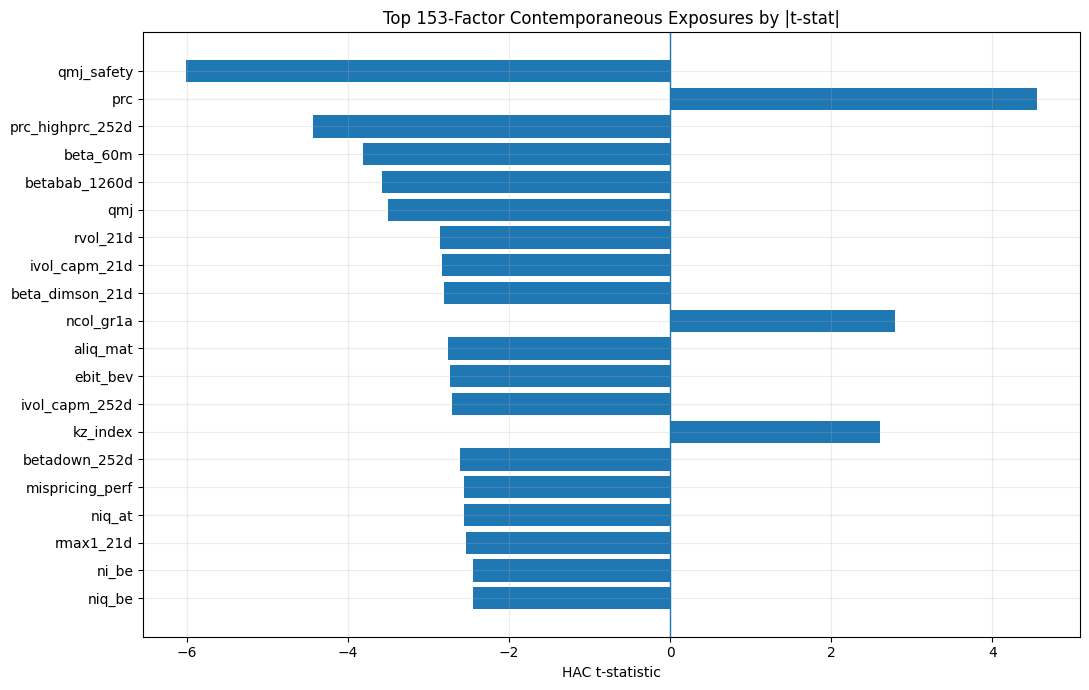

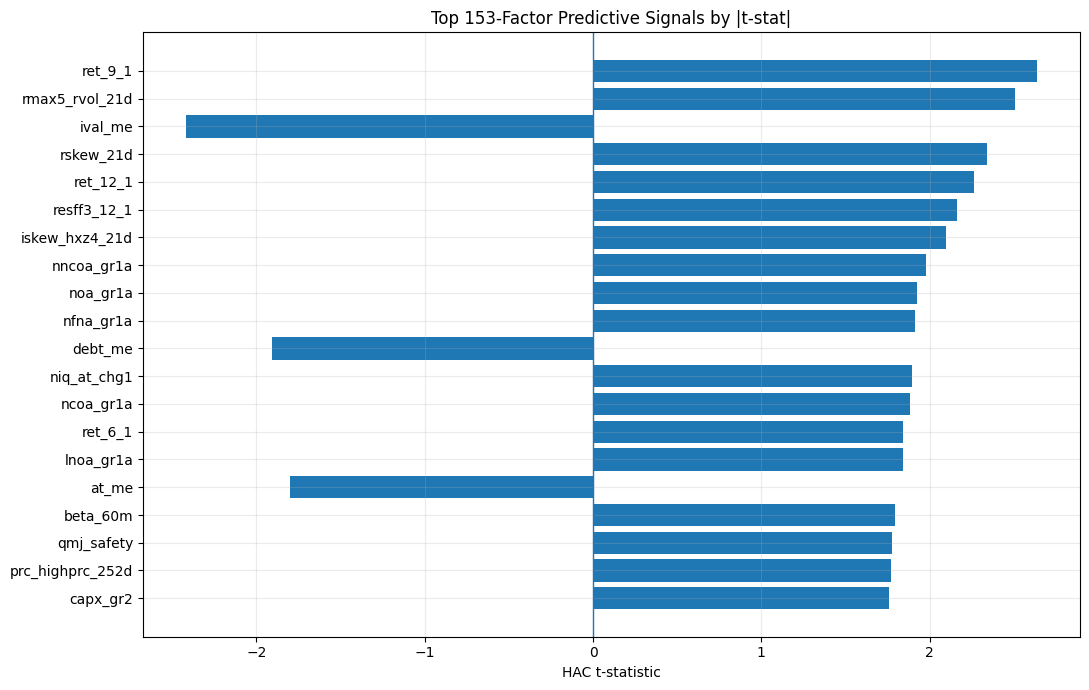

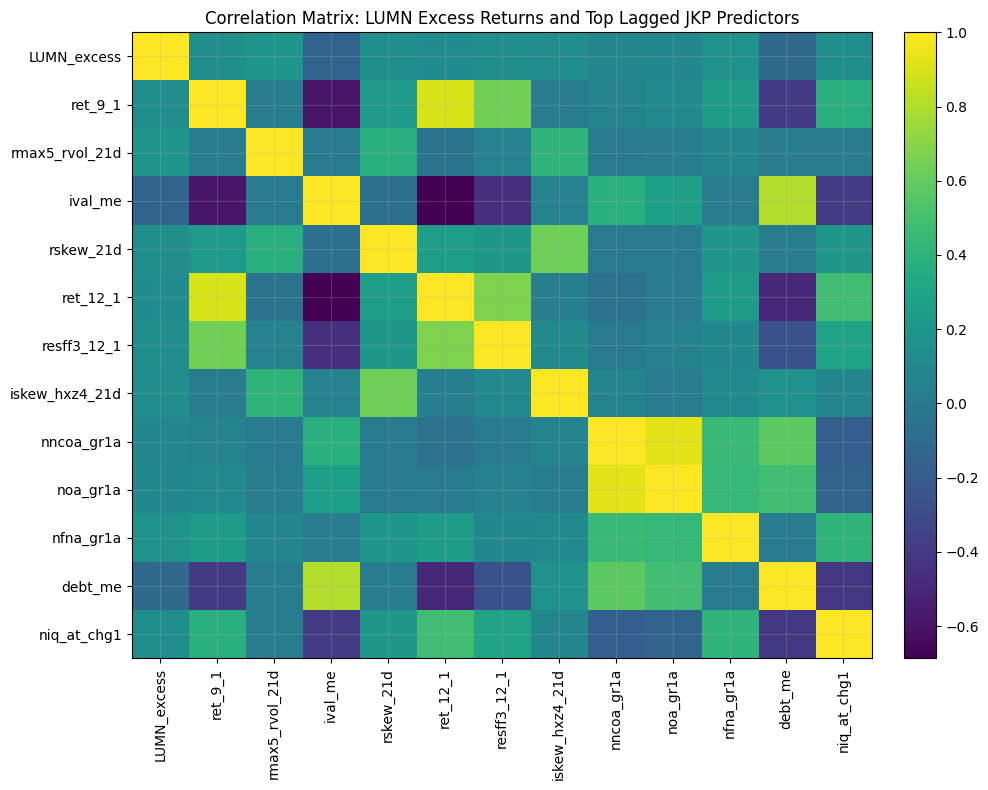

In [31]:

# Visualize the leading factor screens.
for screen_df, title, xcol in [
    (jkp153_contemp, 'Top 153-Factor Contemporaneous Exposures by |t-stat|', 't_beta_HAC'),
    (jkp153_predictive, 'Top 153-Factor Predictive Signals by |t-stat|', 't_beta_HAC')
]:
    top = screen_df.head(20).iloc[::-1]
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(top['factor'], top[xcol])
    ax.axvline(0, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('HAC t-statistic')
    plt.tight_layout()
    plt.show()

# Heatmap-style correlation view for top predictive factors.
top_pred_factors = jkp153_predictive.head(12)['factor'].tolist()
if top_pred_factors:
    corr_mat = pd.concat([jkp153_y, jkp153_X[top_pred_factors].shift(1)], axis=1).dropna().corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr_mat.values, aspect='auto')
    ax.set_xticks(range(len(corr_mat.columns)))
    ax.set_yticks(range(len(corr_mat.index)))
    ax.set_xticklabels(corr_mat.columns, rotation=90)
    ax.set_yticklabels(corr_mat.index)
    ax.set_title('Correlation Matrix: LUMN Excess Returns and Top Lagged JKP Predictors')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


,n_train,n_test,oos_r2_vs_train_mean,rmse,prediction_actual_corr
model,,,,,
elastic_net,124,67,0.0281,0.2944,0.1707
ridge,124,67,0.0151,0.2964,0.2271


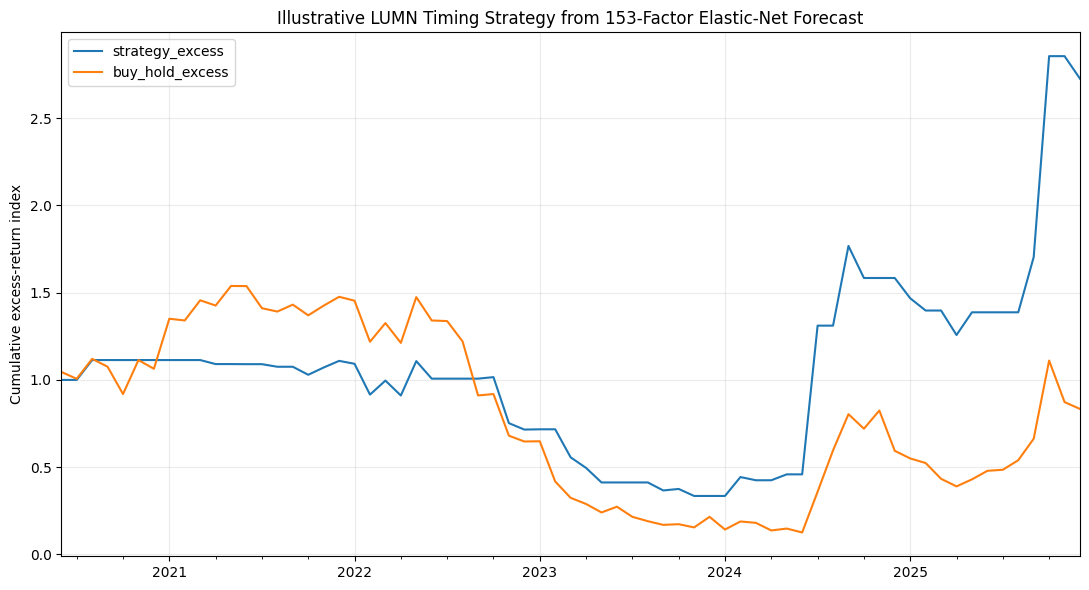

Most important regularized predictors by coefficient magnitude:


,elastic_net_coef,ridge_coef,mean_abs_coef
capx_gr2,0.0198,0.0013,0.0106
qmj,0.0164,0.0009,0.0087
resff3_12_1,0.0051,0.0007,0.0029
iskew_hxz4_21d,0.0033,0.0007,0.0020
cowc_gr1a,-0.0035,-0.0002,0.0018
qmj_safety,0.0000,0.0009,0.0004
beta_60m,0.0000,0.0008,0.0004
beta_dimson_21d,0.0000,0.0008,0.0004
prc_highprc_252d,0.0000,0.0008,0.0004
lnoa_gr1a,0.0000,0.0006,0.0003


In [32]:
# Regularized multivariate forecast using the top predictive factors.
# To keep the notebook responsive, use a single chronological train/test split rather than
# re-fitting ElasticNet hundreds of times in an expanding window.
top_features = jkp153_predictive.head(min(35, EXPANDED_ASSUMPTIONS['jkp153_max_features_for_ml']))['factor'].tolist()
X_lagged = jkp153_X[top_features].shift(EXPANDED_ASSUMPTIONS['jkp153_prediction_lag']) if top_features else pd.DataFrame(index=jkp153_X.index)
ml_data = pd.concat([jkp153_y.rename('y'), X_lagged], axis=1).dropna()

if len(ml_data) >= EXPANDED_ASSUMPTIONS['jkp153_oos_min_train_obs'] + 24 and top_features:
    split = max(EXPANDED_ASSUMPTIONS['jkp153_oos_min_train_obs'], int(len(ml_data) * 0.65))
    train, test = ml_data.iloc[:split], ml_data.iloc[split:]
    X_train, y_train = train.drop(columns='y'), train['y']
    X_test, y_test = test.drop(columns='y'), test['y']
    enet = Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNetCV(l1_ratio=[0.2, 0.5, 0.8, 1.0], cv=5, max_iter=20000, random_state=0))
    ])
    ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('model', RidgeCV(alphas=np.logspace(-4, 4, 30)))
    ])
    models = {'elastic_net': enet, 'ridge': ridge}
    oos_rows = []
    coef_tables = {}
    for name, mdl in models.items():
        mdl.fit(X_train, y_train)
        pred = pd.Series(mdl.predict(X_test), index=X_test.index, name='predicted')
        oos_r2 = 1 - ((y_test - pred)**2).sum() / ((y_test - y_train.mean())**2).sum()
        oos_rows.append({
            'model': name,
            'n_train': len(train),
            'n_test': len(test),
            'oos_r2_vs_train_mean': oos_r2,
            'rmse': np.sqrt(mean_squared_error(y_test, pred)),
            'prediction_actual_corr': y_test.corr(pred),
        })
        final = mdl.named_steps['model']
        coef_tables[name] = pd.Series(final.coef_, index=X_train.columns).sort_values(key=lambda s: s.abs(), ascending=False)
    oos_metrics = pd.DataFrame(oos_rows).set_index('model')
    display(oos_metrics)
    
    # Long/cash timing illustration based on elastic-net prediction.
    pred = pd.Series(models['elastic_net'].predict(X_test), index=X_test.index, name='predicted')
    timing = pd.DataFrame({'actual': y_test, 'predicted': pred})
    timing['signal'] = (timing['predicted'] > 0).astype(float)
    timing['strategy_excess'] = timing['signal'] * timing['actual']
    timing['buy_hold_excess'] = timing['actual']
    timing_wealth = (1 + timing[['strategy_excess', 'buy_hold_excess']]).cumprod()
    ax = timing_wealth.plot()
    ax.set_title('Illustrative LUMN Timing Strategy from 153-Factor Elastic-Net Forecast')
    ax.set_ylabel('Cumulative excess-return index')
    plt.tight_layout()
    plt.show()
    
    feature_importance = pd.DataFrame({
        'elastic_net_coef': coef_tables['elastic_net'],
        'ridge_coef': coef_tables['ridge'],
    }).fillna(0)
    feature_importance['mean_abs_coef'] = feature_importance.abs().mean(axis=1)
    feature_importance = feature_importance.sort_values('mean_abs_coef', ascending=False)
    print('Most important regularized predictors by coefficient magnitude:')
    display(feature_importance.head(25))
else:
    print('Not enough aligned observations to run the train/test elastic-net screen.')


<!-- EXPANDED_PEERS_FF5_153_START -->

## 16. Peer comparisons: fundamentals, ratios, returns, and factor loadings

Peer set supplied in `LUMN_peers.zip`: CCOI, DTEGY, T, VOD, and VZ. LUMN is included from the original ZIP. The comparison emphasizes telecom-style operating measures: revenue growth, margins, ROA/ROE, leverage, interest coverage, capital intensity, and return/factor characteristics.

**Currency note.** DTEGY and VOD accounting statements are in EUR, while the price files are USD ADR/share-price series. The notebook translates EUR-denominated accounting statement values into USD with the editable `eurusd_accounting_translation_rate` for scale measures. Pure ratios such as margin, ROA, ROE, leverage, turnover, and debt/EBITDA are invariant to this translation when numerator and denominator come from the same accounting currency. Market multiples for foreign ADRs can be distorted if ordinary-share counts and ADR ratios differ; these are shown with caution flags rather than treated as definitive valuation facts.


In [33]:

def extract_zip_to_dir(zip_path, extract_dir):
    extract_dir = Path(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)
    return extract_dir

def find_peer_file(peer_root, ticker, contains):
    matches = list(Path(peer_root).rglob(f'{ticker}*{contains}*.csv'))
    return matches[0] if matches else None

def get_series(df, names):
    for name in names:
        if name in df.columns:
            return df[name]
    return pd.Series(index=df.index, dtype=float)

def clean_statement_for_peer(path):
    dated, ttm_ser, raw = load_statement(path)
    return dated.sort_index(), ttm_ser, raw

def ttm_from_quarterly_or_annual(financials, ttm_ser=None):
    # If annual data are supplied, rolling 4 would be wrong. Infer frequency from date spacing.
    if financials.empty:
        return financials
    diffs = financials.index.to_series().diff().dropna().dt.days
    median_days = diffs.median() if len(diffs) else 90
    if median_days > 250:
        # Annual statements: already approximately annual flow data.
        return financials.copy()
    return financials.rolling(4, min_periods=4).sum()

def latest_peer_metrics(ticker, price_path, fin_path, bs_path, currency='USD', eurusd=1.08):
    p = load_prices(price_path)
    f, f_ttm_ser, _ = clean_statement_for_peer(fin_path)
    b, b_ttm_ser, _ = clean_statement_for_peer(bs_path)
    ttm_f = ttm_from_quarterly_or_annual(f, f_ttm_ser)
    common_dates = sorted(set(ttm_f.index).intersection(b.index))
    if not common_dates:
        return None, p, pd.DataFrame()
    ttm_f = ttm_f.loc[common_dates]
    b = b.loc[common_dates]
    b_avg = b.rolling(4, min_periods=2).mean() if len(b) >= 4 else b.expanding(min_periods=1).mean()
    b_avg = b_avg.loc[common_dates]
    d = common_dates[-1]
    multiplier = eurusd if currency == 'EUR' else 1.0
    
    # Pull statement values. Convert scale values when appropriate.
    revenue_s = get_series(ttm_f, ['Total Revenue']) * multiplier
    ebit_s = get_series(ttm_f, ['EBIT', 'Operating Income']) * multiplier
    ebitda_s = get_series(ttm_f, ['EBITDA', 'Normalized EBITDA']) * multiplier
    op_inc_s = get_series(ttm_f, ['Operating Income']) * multiplier
    net_inc_s = get_series(ttm_f, ['Net Income Common Stockholders', 'Net Income']) * multiplier
    interest_s = get_series(ttm_f, ['Interest Expense', 'Interest Expense Non Operating']).abs() * multiplier
    dep_s = get_series(ttm_f, ['Reconciled Depreciation', 'Depreciation']) * multiplier
    gross_profit_s = get_series(ttm_f, ['Gross Profit']) * multiplier
    shares_s = get_series(ttm_f, ['Diluted Average Shares', 'Basic Average Shares'])
    
    assets_s = get_series(b, ['Total Assets']) * multiplier
    avg_assets_s = get_series(b_avg, ['Total Assets']) * multiplier
    curr_assets_s = get_series(b, ['Current Assets']) * multiplier
    cash_s = get_series(b, ['Cash, Cash Equivalents & Short Term Investments', 'Cash And Cash Equivalents']) * multiplier
    receivables_s = get_series(b, ['Receivables', 'Accounts receivable']) * multiplier
    curr_liab_s = get_series(b, ['Current Liabilities']) * multiplier
    total_liab_s = get_series(b, ['Total Liabilities Net Minority Interest']) * multiplier
    debt_s = get_series(b, ['Total Debt']) * multiplier
    if debt_s.isna().all():
        debt_s = (get_series(b, ['Current Debt And Capital Lease Obligation']).fillna(0) +
                  get_series(b, ['Long Term Debt And Capital Lease Obligation']).fillna(0)) * multiplier
    equity_s = get_series(b, ['Common Stock Equity', "Stockholders' Equity"]) * multiplier
    avg_equity_s = get_series(b_avg, ['Common Stock Equity', "Stockholders' Equity"]) * multiplier
    ppe_s = get_series(b_avg, ['Net PPE']) * multiplier
    
    latest_price = p['Adj Close'].dropna().iloc[-1] if not p['Adj Close'].dropna().empty else np.nan
    shares_latest = shares_s.loc[d] if d in shares_s.index else np.nan
    market_cap_rough = latest_price * shares_latest if pd.notna(latest_price) and pd.notna(shares_latest) else np.nan
    net_debt_s = debt_s - cash_s
    ev_rough = market_cap_rough + net_debt_s.loc[d] if pd.notna(market_cap_rough) and d in net_debt_s.index else np.nan
    
    # Growth rates.
    rev_yoy = revenue_s.pct_change(4).loc[d] if len(revenue_s.dropna()) >= 5 else revenue_s.pct_change().loc[d]
    ebitda_yoy = ebitda_s.pct_change(4).loc[d] if len(ebitda_s.dropna()) >= 5 else ebitda_s.pct_change().loc[d]
    
    metrics = {
        'ticker': ticker,
        'currency_statement': currency,
        'latest_statement_date': d,
        'revenue_ttm_usd': revenue_s.loc[d],
        'revenue_growth_yoy': rev_yoy,
        'gross_margin': safe_div(gross_profit_s.loc[d], revenue_s.loc[d]),
        'operating_margin': safe_div(op_inc_s.loc[d], revenue_s.loc[d]),
        'ebitda_margin': safe_div(ebitda_s.loc[d], revenue_s.loc[d]),
        'net_margin': safe_div(net_inc_s.loc[d], revenue_s.loc[d]),
        'roa': safe_div(net_inc_s.loc[d], avg_assets_s.loc[d]),
        'roe': safe_div(net_inc_s.loc[d], avg_equity_s.loc[d]),
        'asset_turnover': safe_div(revenue_s.loc[d], avg_assets_s.loc[d]),
        'ppe_turnover': safe_div(revenue_s.loc[d], ppe_s.loc[d]),
        'current_ratio': safe_div(curr_assets_s.loc[d], curr_liab_s.loc[d]),
        'quick_ratio': safe_div(cash_s.loc[d] + receivables_s.loc[d], curr_liab_s.loc[d]),
        'debt_to_assets': safe_div(debt_s.loc[d], assets_s.loc[d]),
        'liabilities_to_assets': safe_div(total_liab_s.loc[d], assets_s.loc[d]),
        'debt_to_equity': safe_div(debt_s.loc[d], equity_s.loc[d]),
        'net_debt_to_ebitda': safe_div(net_debt_s.loc[d], ebitda_s.loc[d]),
        'debt_to_ebitda': safe_div(debt_s.loc[d], ebitda_s.loc[d]),
        'interest_coverage_ebitda': safe_div(ebitda_s.loc[d], interest_s.loc[d]),
        'interest_coverage_ebit': safe_div(ebit_s.loc[d], interest_s.loc[d]),
        'dep_to_revenue': safe_div(dep_s.loc[d], revenue_s.loc[d]),
        'net_debt_usd': net_debt_s.loc[d],
        'market_cap_rough_usd': market_cap_rough,
        'ev_rough_usd': ev_rough,
        'price_to_sales_rough': safe_div(market_cap_rough, revenue_s.loc[d]),
        'ev_to_revenue_rough': safe_div(ev_rough, revenue_s.loc[d]),
        'ev_to_ebitda_rough': safe_div(ev_rough, ebitda_s.loc[d]),
        'market_multiple_caution': 'ADR/share-count and/or FX caveat' if currency == 'EUR' else '',
    }
    
    # Ratio panel for plotting over time.
    panel = pd.DataFrame(index=common_dates)
    panel['revenue_ttm_usd'] = revenue_s
    panel['ebitda_margin'] = ebitda_s / revenue_s
    panel['operating_margin'] = op_inc_s / revenue_s
    panel['net_margin'] = net_inc_s / revenue_s
    panel['roa'] = net_inc_s / avg_assets_s
    panel['roe'] = net_inc_s / avg_equity_s
    panel['debt_to_assets'] = debt_s / assets_s
    panel['net_debt_to_ebitda'] = net_debt_s / ebitda_s
    panel['interest_coverage_ebitda'] = ebitda_s / interest_s
    panel['asset_turnover'] = revenue_s / avg_assets_s
    panel['current_ratio'] = curr_assets_s / curr_liab_s
    panel['quick_ratio'] = (cash_s + receivables_s) / curr_liab_s
    panel['ticker'] = ticker
    return metrics, p, panel


In [34]:

# Extract peers and build comparison panels.
PEER_ROOT = extract_zip_to_dir(EXPANDED_ZIP_PATHS['peers_zip'], Path('/mnt/data/LUMN_peers_extracted'))
# Inner folder may exist depending on zip structure.
peer_base = PEER_ROOT / 'LUMN_peers' if (PEER_ROOT / 'LUMN_peers').exists() else PEER_ROOT

peer_currency = {
    'LUMN': 'USD',
    'CCOI': 'USD',
    'DTEGY': 'EUR',  # User note: accounting data in EUR. Ticker file uses DTEGY spelling in supplied data.
    'T': 'USD',
    'VOD': 'EUR',
    'VZ': 'USD',
}
peer_tickers = ['LUMN', 'CCOI', 'DTEGY', 'T', 'VOD', 'VZ']

peer_metrics = []
peer_prices = {}
peer_panels = []

# LUMN from original DATA_DIR.
lumn_metrics, lumn_price_obj, lumn_panel = latest_peer_metrics(
    'LUMN', DATA_DIR / 'LUMN_monthly.csv', DATA_DIR / 'LUMN_quarterly_financials.csv', DATA_DIR / 'LUMN_quarterly_balance-sheet.csv',
    currency='USD', eurusd=EXPANDED_ASSUMPTIONS['eurusd_accounting_translation_rate']
)
peer_metrics.append(lumn_metrics)
peer_prices['LUMN'] = lumn_price_obj
peer_panels.append(lumn_panel)

for ticker in ['CCOI', 'DTEGY', 'T', 'VOD', 'VZ']:
    price_path = peer_base / f'{ticker}.csv'
    fin_path = find_peer_file(peer_base, ticker, 'financials')
    bs_path = find_peer_file(peer_base, ticker, 'balance-sheet')
    if price_path.exists() and fin_path and bs_path:
        m, p, panel = latest_peer_metrics(
            ticker, price_path, fin_path, bs_path,
            currency=peer_currency[ticker],
            eurusd=EXPANDED_ASSUMPTIONS['eurusd_accounting_translation_rate']
        )
        peer_metrics.append(m)
        peer_prices[ticker] = p
        peer_panels.append(panel)
    else:
        print('Missing peer files for', ticker, price_path, fin_path, bs_path)

peer_metrics_df = pd.DataFrame(peer_metrics).set_index('ticker')
peer_metrics_df = peer_metrics_df.sort_index()
peer_ratio_panel = pd.concat(peer_panels).reset_index().rename(columns={'index': 'date'}).set_index(['ticker', 'date']).sort_index()

print('Peer latest metric table')
display(peer_metrics_df)


Peer latest metric table


,currency_statement,latest_statement_date,revenue_ttm_usd,revenue_growth_yoy,gross_margin,operating_margin,ebitda_margin,net_margin,roa,roe,asset_turnover,ppe_turnover,current_ratio,quick_ratio,debt_to_assets,liabilities_to_assets,debt_to_equity,net_debt_to_ebitda,debt_to_ebitda,interest_coverage_ebitda,interest_coverage_ebit,dep_to_revenue,net_debt_usd,market_cap_rough_usd,ev_rough_usd,price_to_sales_rough,ev_to_revenue_rough,ev_to_ebitda_rough,market_multiple_caution
ticker,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CCOI,USD,2026-03-31,"967,907,000.0000",-0.0483,0.4558,-0.0826,0.2025,-0.1753,-0.0540,4.2283,0.3079,0.4750,1.9033,1.4273,0.8708,1.0341,-25.5539,12.8648,13.5805,1.1298,-0.3009,0.2564,"2,521,483,000.0000","3,209,394,174.0300","5,730,877,174.0300",3.3158,5.9209,29.2395,
DTEGY,EUR,2026-03-31,"127,926,000,000.0000",0.0132,0.6090,0.2138,0.4114,0.0744,0.0306,0.1436,0.4113,1.3188,1.1800,NaN,0.4864,0.6864,2.2559,2.6606,2.9294,7.5071,3.7545,0.2057,"140,040,360,000.0000","618,498,769,347.6833","758,539,129,347.6833",4.8348,5.9295,14.4113,ADR/share-count and/or FX caveat
LUMN,USD,2026-03-31,"12,119,000,000.0000",-0.0678,0.4731,-0.0235,0.1294,-0.1434,-0.0526,1.6545,0.3666,0.6273,0.9880,0.7801,0.4327,1.0430,-10.0607,7.4139,8.4503,1.3494,-0.9742,0.2228,"11,625,000,000.0000","35,513,602,740.0000","47,138,602,740.0000",2.9304,3.8896,30.0629,
T,USD,2025-12-31,"125,648,000,000.0000",0.0271,0.5955,0.1990,0.4353,0.1742,0.0532,0.2035,0.3053,0.8282,0.9061,0.5035,0.3690,0.6942,1.4027,2.5012,2.8346,8.0389,4.9693,0.1662,"136,809,000,000.0000","653,357,250,000.0000","790,166,250,000.0000",5.1999,6.2887,14.4462,
VOD,EUR,2026-03-31,"43,697,880,000.0000",0.0932,0.3147,0.0925,0.4144,-0.0098,-0.0028,-0.0070,0.2899,1.2317,1.1374,NaN,0.4051,0.5815,1.0396,2.4039,3.1393,6.8465,1.7611,0.3078,"43,531,560,000.0000","35,328,510,000.0000","78,860,070,000.0000",0.8085,1.8047,4.3549,ADR/share-count and/or FX caveat
VZ,USD,2026-03-31,"139,146,000,000.0000",0.0285,0.5876,0.2122,0.3496,0.1246,0.0435,0.1668,0.3492,1.0183,0.6400,0.5012,0.4687,0.7496,1.8960,3.8543,4.0262,6.9479,4.2823,0.1341,"187,506,000,000.0000","767,070,573,093.0000","954,576,573,093.0000",5.5127,6.8603,19.6217,


Peer monthly return statistics


,start,end,n_months,ann_return_CAGR,ann_vol,sharpe_ex_rf0,skewness,excess_kurtosis,max_drawdown
LUMN,2010-01-31,2026-06-30,198.0000,-0.0156,0.6513,-0.0239,5.3023,48.4955,-0.9464
CCOI,2010-01-31,2026-06-30,198.0000,0.0733,0.3326,0.2203,-1.0795,4.8850,-0.7726
DTEGY,2010-01-31,2026-06-30,198.0000,0.1015,0.2444,0.4153,0.0592,0.6272,-0.3685
T,2010-01-31,2026-06-30,198.0000,0.0840,0.1917,0.4383,-0.1154,0.7531,-0.3468
VOD,2010-01-31,2026-06-30,198.0000,0.0324,0.2450,0.1321,0.0268,0.4855,-0.6173
VZ,2010-01-31,2026-06-30,198.0000,0.0816,0.1806,0.4518,0.0553,-0.3471,-0.3783


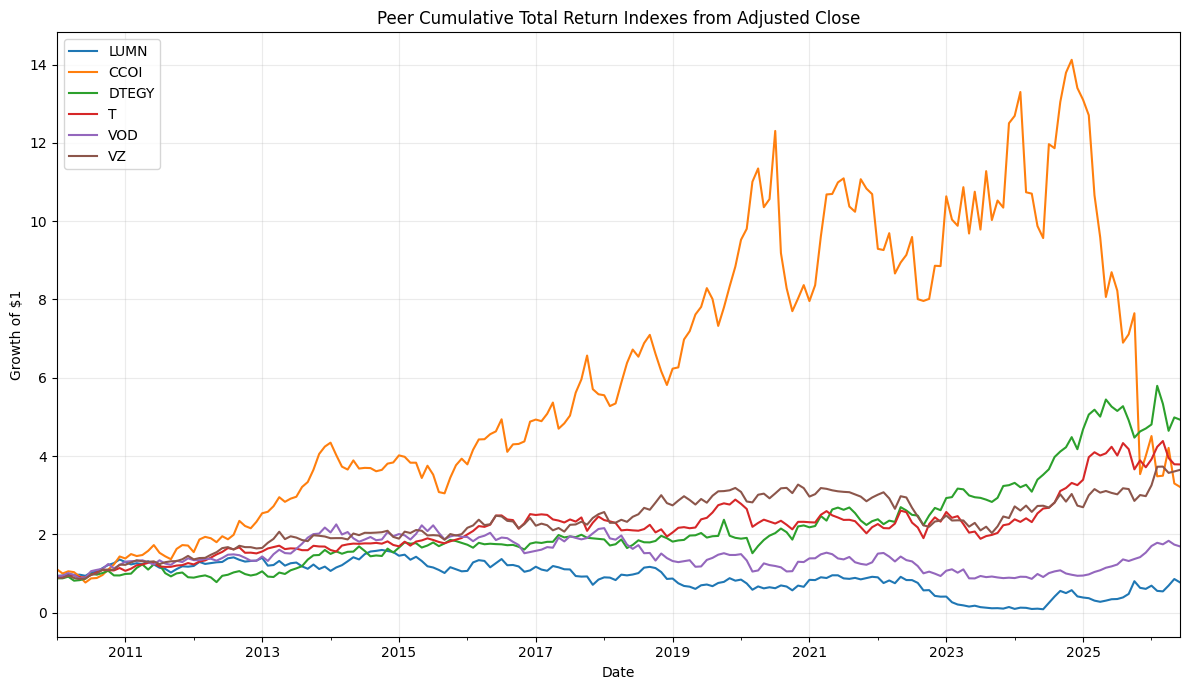

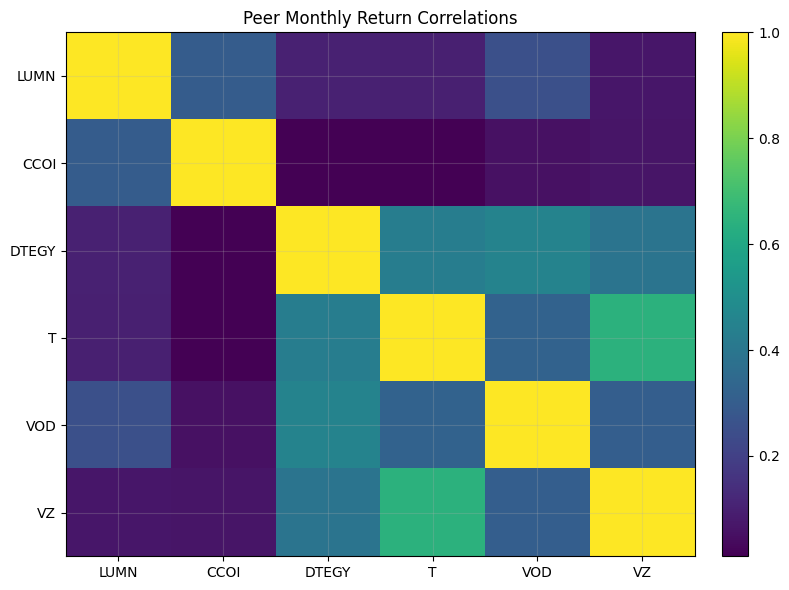

In [35]:

# Peer return comparisons.
peer_monthly_returns = {}
for ticker, price_df in peer_prices.items():
    r = price_df['Adj Close'].pct_change().dropna()
    r = r.loc[r.index >= pd.Timestamp(EXPANDED_ASSUMPTIONS['peer_price_start_date'])]
    # Align to month-end for factor regressions and cross-peer stats.
    r.index = r.index.to_period('M').to_timestamp('M')
    peer_monthly_returns[ticker] = r.groupby(level=0).last()
peer_rets = pd.DataFrame(peer_monthly_returns).dropna(how='all').sort_index()
peer_cum = (1 + peer_rets.fillna(0)).cumprod()

peer_return_stats = pd.DataFrame(index=peer_rets.columns)
for ticker in peer_rets.columns:
    r = peer_rets[ticker].dropna()
    peer_return_stats.loc[ticker, 'start'] = r.index.min()
    peer_return_stats.loc[ticker, 'end'] = r.index.max()
    peer_return_stats.loc[ticker, 'n_months'] = len(r)
    peer_return_stats.loc[ticker, 'ann_return_CAGR'] = annualize_return(r, 12)
    peer_return_stats.loc[ticker, 'ann_vol'] = annualize_vol(r, 12)
    peer_return_stats.loc[ticker, 'sharpe_ex_rf0'] = peer_return_stats.loc[ticker, 'ann_return_CAGR'] / peer_return_stats.loc[ticker, 'ann_vol']
    peer_return_stats.loc[ticker, 'skewness'] = r.skew()
    peer_return_stats.loc[ticker, 'excess_kurtosis'] = r.kurtosis()
    peer_return_stats.loc[ticker, 'max_drawdown'] = max_drawdown((1+r).cumprod())

print('Peer monthly return statistics')
display(peer_return_stats)

ax = peer_cum.plot(figsize=(12, 7))
ax.set_title('Peer Cumulative Total Return Indexes from Adjusted Close')
ax.set_ylabel('Growth of $1')
plt.tight_layout()
plt.show()

corr = peer_rets.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.index)
ax.set_title('Peer Monthly Return Correlations')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


Peer FF5 monthly factor loadings


,n_obs,alpha_ann,adj_r2,beta_Mkt-RF,beta_SMB,beta_HML,beta_RMW,beta_CMA
ticker,,,,,,,,
CCOI,196,0.0616,0.0813,0.6199,0.0828,-0.4389,-0.4482,0.3153
DTEGY,196,0.0110,0.1648,0.6497,-0.0161,0.1046,0.6381,0.3168
LUMN,196,0.0195,0.0858,0.8652,1.1585,0.3525,-0.3142,0.3203
T,196,0.0099,0.2779,0.4802,0.0658,0.1238,0.7260,0.7175
VOD,196,-0.0470,0.2069,0.7435,-0.2559,0.4319,0.1572,0.1429
VZ,196,0.0043,0.2093,0.4736,-0.2985,-0.0986,0.4292,0.8179


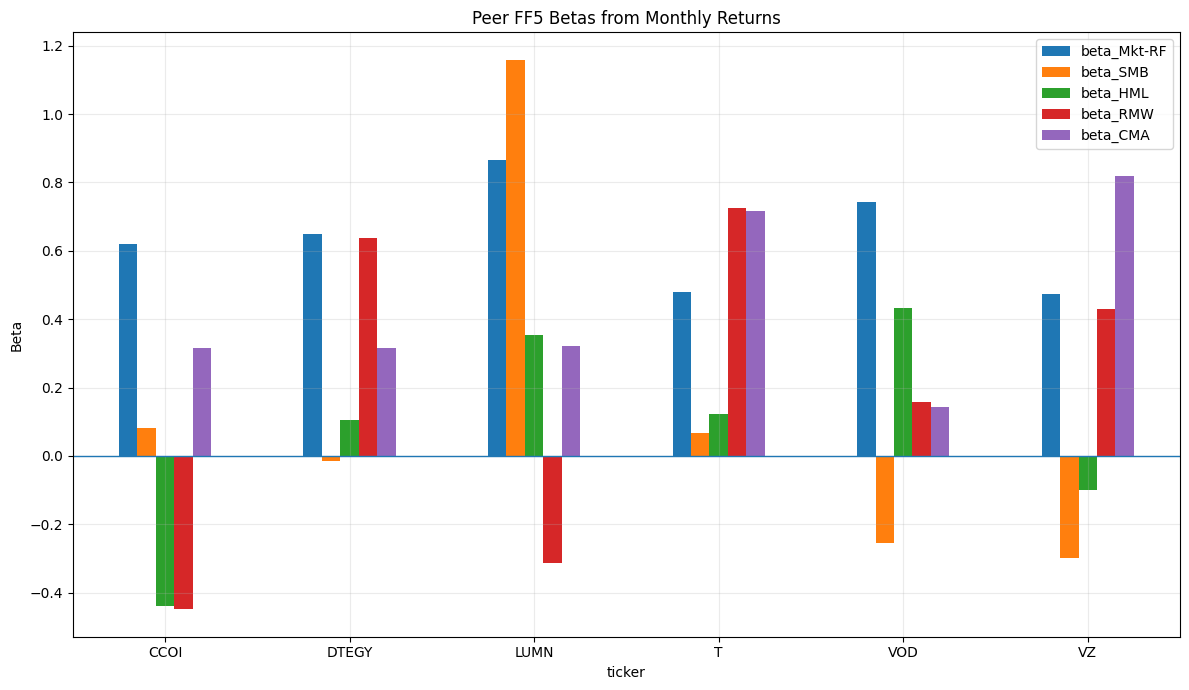

In [36]:

# Peer FF5 monthly loadings.
peer_ff5_rows = []
for ticker in peer_rets.columns:
    common, model, tbl = align_factor_regression(peer_rets[ticker].dropna().rename(ticker), ff5_m.loc[ff5_m.index >= start], 'monthly')
    if model is None:
        continue
    row = {'ticker': ticker, 'n_obs': len(common), 'alpha_ann': model.params.get('const', np.nan) * 12, 'adj_r2': model.rsquared_adj}
    for factor in [c for c in ff5_m.columns if c != 'RF']:
        row[f'beta_{factor}'] = model.params.get(factor, np.nan)
    peer_ff5_rows.append(row)
peer_ff5_loadings = pd.DataFrame(peer_ff5_rows).set_index('ticker').sort_index()
print('Peer FF5 monthly factor loadings')
display(peer_ff5_loadings)

beta_cols = [c for c in peer_ff5_loadings.columns if c.startswith('beta_')]
if beta_cols:
    ax = peer_ff5_loadings[beta_cols].plot(kind='bar', figsize=(12, 7))
    ax.set_title('Peer FF5 Betas from Monthly Returns')
    ax.axhline(0, linewidth=1)
    ax.set_ylabel('Beta')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


Selected latest peer ratios and metrics


,revenue_growth_yoy,ebitda_margin,operating_margin,net_margin,roa,roe,asset_turnover,debt_to_assets,net_debt_to_ebitda,interest_coverage_ebitda,current_ratio,ev_to_ebitda_rough
ticker,,,,,,,,,,,,
CCOI,-0.0483,0.2025,-0.0826,-0.1753,-0.0540,4.2283,0.3079,0.8708,12.8648,1.1298,1.9033,29.2395
DTEGY,0.0132,0.4114,0.2138,0.0744,0.0306,0.1436,0.4113,0.4864,2.6606,7.5071,1.1800,14.4113
LUMN,-0.0678,0.1294,-0.0235,-0.1434,-0.0526,1.6545,0.3666,0.4327,7.4139,1.3494,0.9880,30.0629
T,0.0271,0.4353,0.1990,0.1742,0.0532,0.2035,0.3053,0.3690,2.5012,8.0389,0.9061,14.4462
VOD,0.0932,0.4144,0.0925,-0.0098,-0.0028,-0.0070,0.2899,0.4051,2.4039,6.8465,1.1374,4.3549
VZ,0.0285,0.3496,0.2122,0.1246,0.0435,0.1668,0.3492,0.4687,3.8543,6.9479,0.6400,19.6217


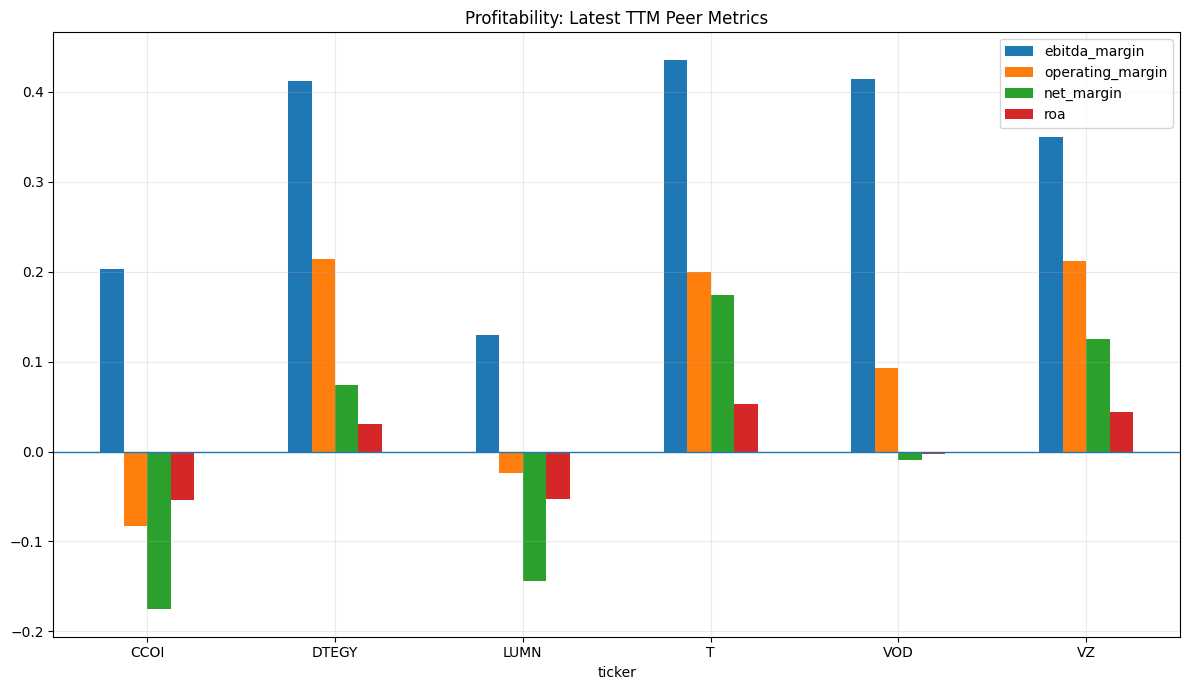

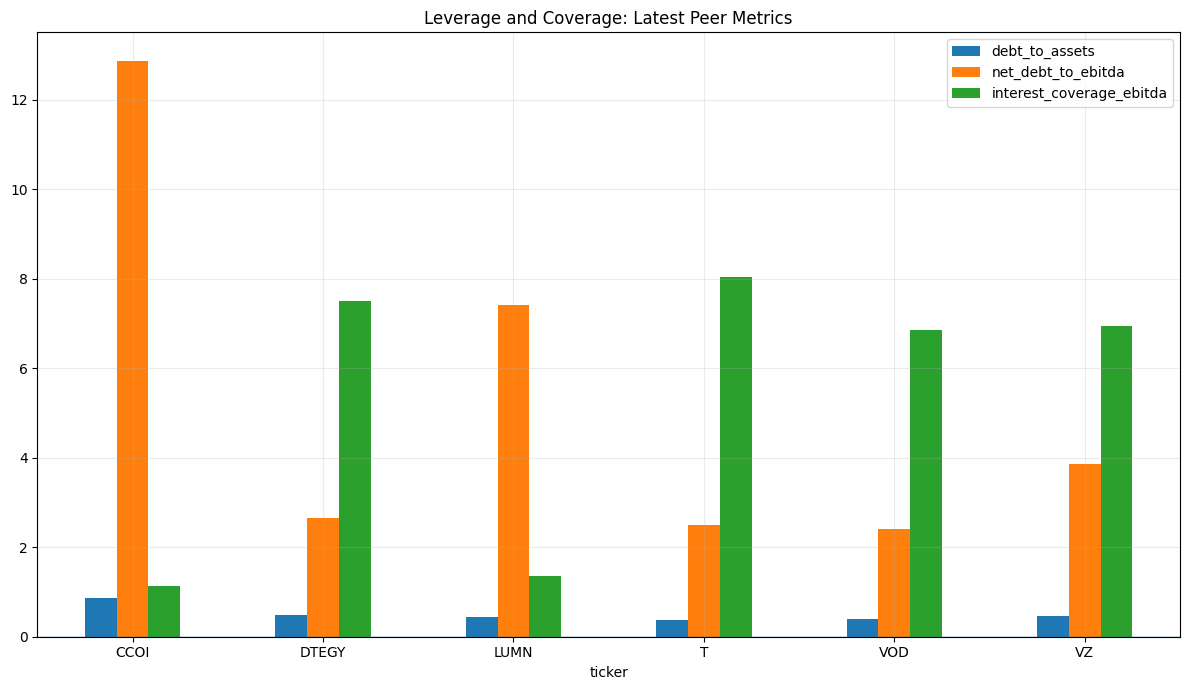

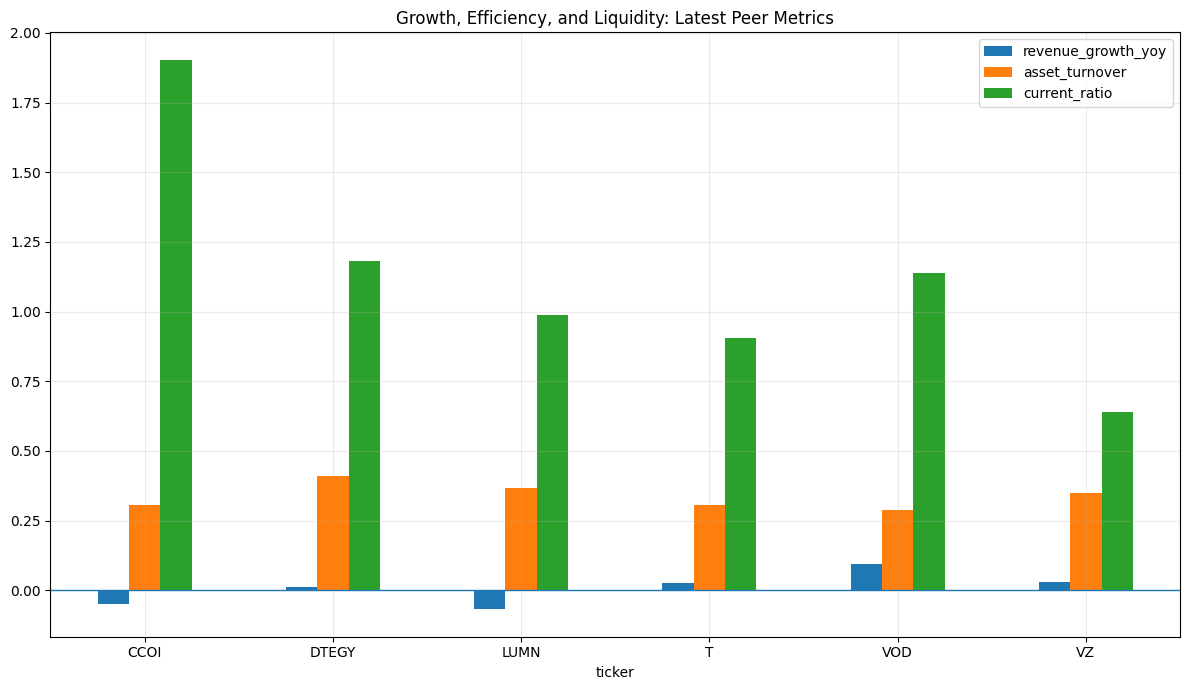

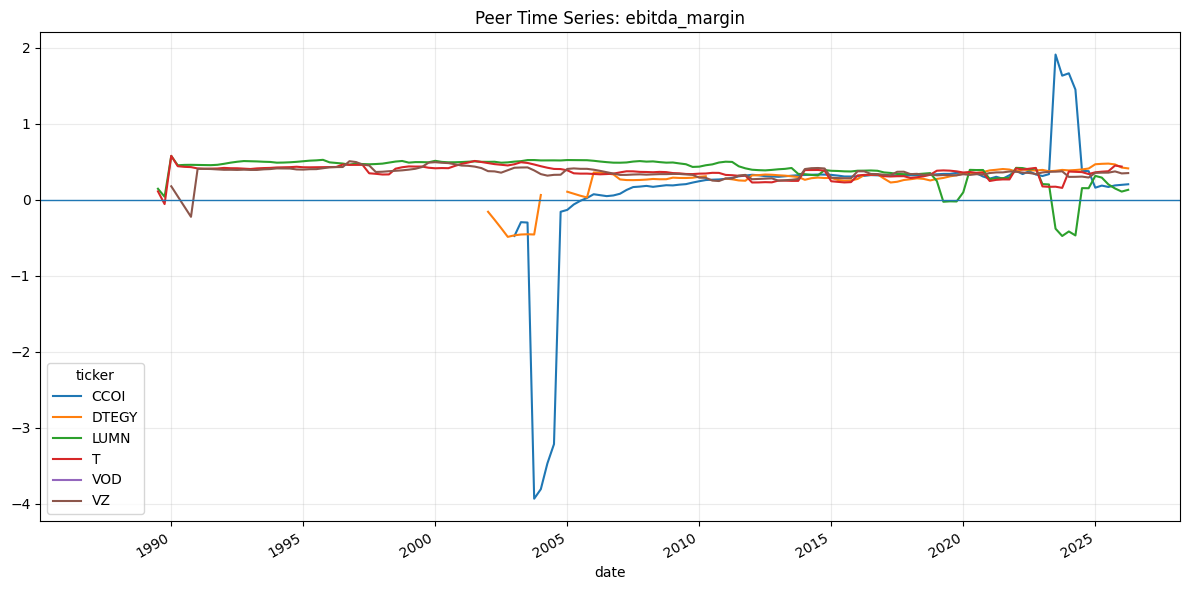

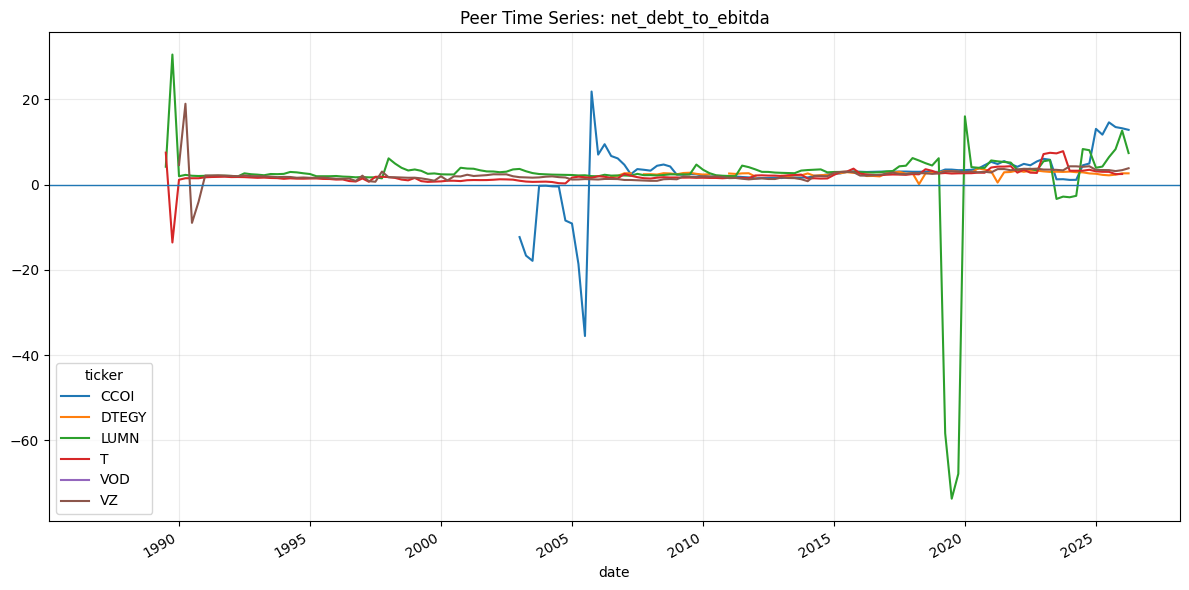

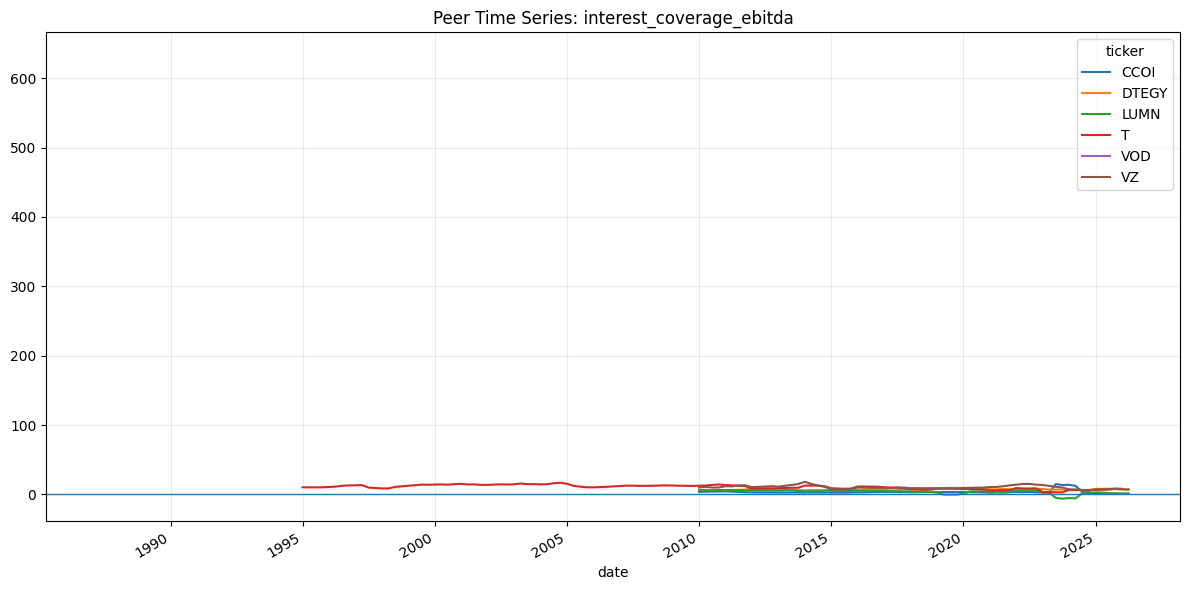

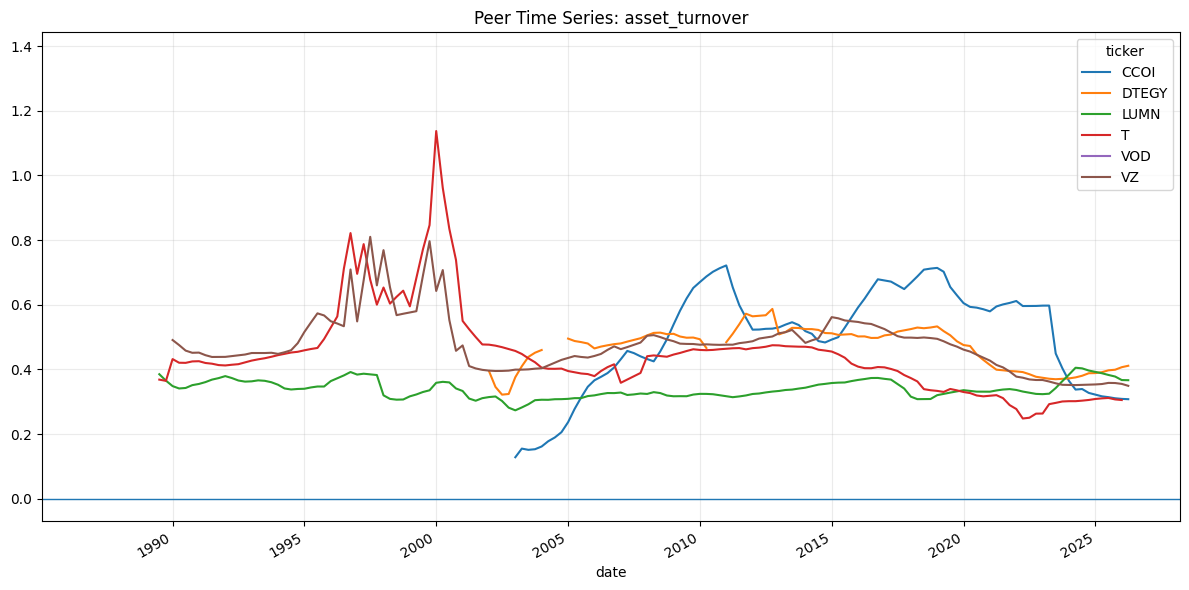

In [37]:

# Latest peer fundamental comparison charts.
comparison_cols = [
    'revenue_growth_yoy', 'ebitda_margin', 'operating_margin', 'net_margin', 'roa', 'roe',
    'asset_turnover', 'debt_to_assets', 'net_debt_to_ebitda', 'interest_coverage_ebitda',
    'current_ratio', 'ev_to_ebitda_rough'
]
available_comp_cols = [c for c in comparison_cols if c in peer_metrics_df.columns]
peer_comp = peer_metrics_df[available_comp_cols].copy()
print('Selected latest peer ratios and metrics')
display(peer_comp)

for cols, title in [
    (['ebitda_margin', 'operating_margin', 'net_margin', 'roa'], 'Profitability: Latest TTM Peer Metrics'),
    (['debt_to_assets', 'net_debt_to_ebitda', 'interest_coverage_ebitda'], 'Leverage and Coverage: Latest Peer Metrics'),
    (['revenue_growth_yoy', 'asset_turnover', 'current_ratio'], 'Growth, Efficiency, and Liquidity: Latest Peer Metrics'),
]:
    cols = [c for c in cols if c in peer_metrics_df.columns]
    if cols:
        ax = peer_metrics_df[cols].plot(kind='bar', figsize=(12, 7))
        ax.set_title(title)
        ax.axhline(0, linewidth=1)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

# Time-series comparison for a few ratios.
for metric in ['ebitda_margin', 'net_debt_to_ebitda', 'interest_coverage_ebitda', 'asset_turnover']:
    if metric in peer_ratio_panel.columns:
        plot_df = peer_ratio_panel[metric].unstack('ticker')
        ax = plot_df.plot(figsize=(12, 6))
        ax.set_title(f'Peer Time Series: {metric}')
        ax.axhline(0, linewidth=1)
        plt.tight_layout()
        plt.show()


<!-- EXPANDED_PEERS_FF5_153_START -->

## 17. Expanded synthesis checklist

Use the cells above to update the single-company interpretation:

- **FF5:** compare LUMN's monthly and daily loadings. If the market beta is high while profitability/investment loadings are adverse, cost of equity will be dominated by market risk and distress/turnaround covariance rather than stable income-stock characteristics.
- **153-factor screen:** focus on factors that survive FDR adjustment or remain important in the regularized model. Treat the timing exercise as exploratory, not an investment rule.
- **Peer fundamentals:** compare LUMN against T/VZ for scale and debt burden, CCOI for growth/asset-light contrast, and DTEGY/VOD for international telecom comparables. Use the EUR/USD assumption for size comparisons, but rely more heavily on currency-invariant ratios for cross-border interpretation.
- **Valuation:** use LUMN's WACC and FCF-proxy valuation above, then benchmark implied EV/revenue and EV/EBITDA against peers with the ADR/share-count caveat for DTEGY/VOD.
